In [1]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf

In [2]:
# set up Jacob's anayltic expression for TWA two-90deg hybrid S matrix 

def S_mat(theta):
    row1 = [0, -1+np.exp(1j*theta), 1j + 1j*np.exp(1j*theta), 0]
    row2 = [-1+np.exp(1j*theta), 0, 0, 1j + 1j*np.exp(1j*theta)]
    row3 = [1j + 1j*np.exp(1j*theta), 0, 0, 1 -np.exp(1j*theta)]
    row4 = [0, 1j + 1j*np.exp(1j*theta), 1 -np.exp(1j*theta), 0]
    return np.array([row1, row2, row3, row4])/2

def S_mat_90deg_hybrid():
    row1 = [0, 1j, 1, 0]
    row2 = [1j, 0, 0, 1]
    row3 = [1, 0, 0, 1j]
    row4 = [0, 1, 1j, 0]
    return -np.array([row1, row2, row3, row4])/np.sqrt(2)


nominal = np.array([1, 0, 0, 1]).T # collumn vector of two identical input excitations

theta_array = np.linspace(0, 2*np.pi, 100)
R = np.zeros_like(theta_array, dtype='complex')
A = np.zeros_like(theta_array, dtype='complex')
D = np.zeros_like(theta_array, dtype='complex')
G = np.zeros_like(theta_array, dtype='complex')

for i in range(theta_array.shape[0]):
    S = S_mat(theta_array[i])
    result = np.matmul(S, nominal)
    R[i] = result[0]
    A[i] = result[1]
    D[i] = result[2]
    G[i] = result[3]


In [6]:
A = 2
B = 6
print(np.abs(A + 1j*B))
print(np.abs(1j*A + B))


6.324555320336759
6.324555320336759


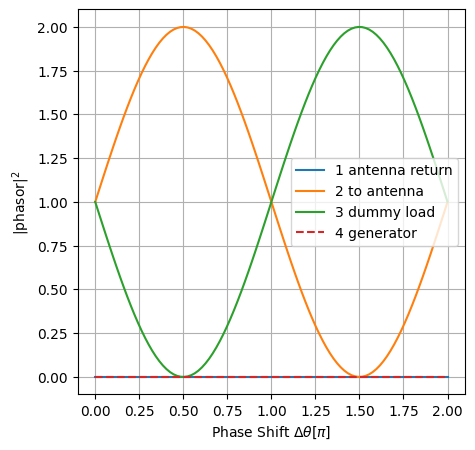

In [184]:
fig, ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(theta_array/np.pi, np.abs(R)**2, label='1 antenna return')
ax.plot(theta_array/np.pi, np.abs(A)**2, label='2 to antenna')
ax.plot(theta_array/np.pi, np.abs(D)**2, label='3 dummy load')
ax.plot(theta_array/np.pi, np.abs(G)**2, label='4 generator', linestyle='--')

ax.set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()
ax.grid()

In [185]:
# now, test mismatch in input signal for a fixed phase shift of pi/2:

mismatch = np.array([0, 0, 0, 1], dtype='complex').T # collumn vector of two identical input excitations, one will be shifted by exp(1j*phi)

phi_array = np.linspace(0, 2*np.pi, 100)
R_mismatch = np.zeros_like(phi_array, dtype='complex')
A_mismatch = np.zeros_like(phi_array, dtype='complex')
D_mismatch = np.zeros_like(phi_array, dtype='complex')
G_mismatch = np.zeros_like(phi_array, dtype='complex')

for i in range(phi_array.shape[0]):

    mismatch[0] = 1*np.exp(1j*phi_array[i]) # update the antenna return to be mismatched  
    S = S_mat(theta=np.pi/2)  # fix the phase shifter to the value for which nominally the dummy load is zero 
    result = np.matmul(S, mismatch)
    R_mismatch[i] = result[0]
    A_mismatch[i] = result[1]
    D_mismatch[i] = result[2]
    G_mismatch[i] = result[3]




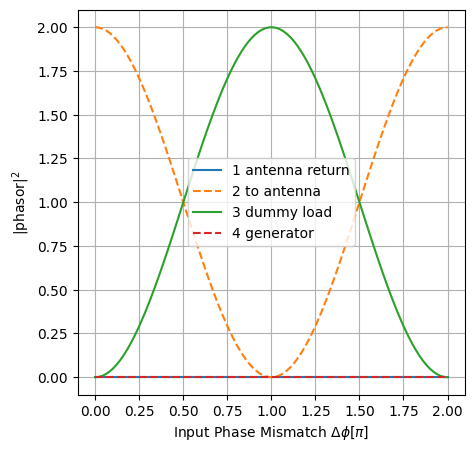

In [186]:
# plot  mags
fig, ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(phi_array/np.pi, np.abs(R_mismatch)**2, label='1 antenna return')
ax.plot(phi_array/np.pi, np.abs(A_mismatch)**2, label='2 to antenna', linestyle='--')
ax.plot(phi_array/np.pi, np.abs(D_mismatch)**2, label='3 dummy load')
ax.plot(phi_array/np.pi, np.abs(G_mismatch)**2, label='4 generator', linestyle='--')

ax.set_xlabel('Input Phase Mismatch' r' $\Delta \phi [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()
ax.grid()

In [187]:
print(R.shape)
print(np.arctan2(np.imag(R), np.real(R)).shape)

(100,)
(100,)


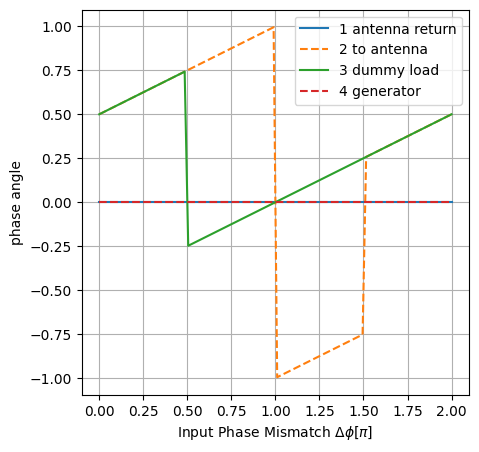

In [188]:
# plot phases

# plot  mags
fig, ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(phi_array/np.pi, np.arctan2(np.imag(R), np.real(R))/np.pi, label='1 antenna return')
ax.plot(phi_array/np.pi, np.arctan2(np.imag(A), np.real(A))/np.pi, label='2 to antenna', linestyle='--')
ax.plot(phi_array/np.pi, np.arctan2(np.imag(D), np.real(D))/np.pi, label='3 dummy load')
ax.plot(phi_array/np.pi, np.arctan2(np.imag(G), np.real(G))/np.pi, label='4 generator', linestyle='--')

ax.set_xlabel('Input Phase Mismatch' r' $\Delta \phi [\pi$]')
ax.set_ylabel(r'phase angle')
ax.legend()
ax.grid()


In [189]:
# now, test mismatch in reflected signal for a fixed phase shift of pi/2:

mismatch = np.array([1, 0, 0, 1], dtype='complex').T # collumn vector of two identical input excitations, one will be shifted by exp(1j*phi)

phi_array = np.linspace(0, 2*np.pi, 100)
R_mismatch = np.zeros_like(phi_array, dtype='complex')
A_mismatch = np.zeros_like(phi_array, dtype='complex')
D_mismatch = np.zeros_like(phi_array, dtype='complex')
G_mismatch = np.zeros_like(phi_array, dtype='complex')

for i in range(phi_array.shape[0]):

    mismatch[1] = np.exp(1j*phi_array[i]) # update the antenna return to be mismatched  
    S = S_mat(theta=np.pi/2)  # fix the phase shifter to the value for which nominally the dummy load is zero 
    result = np.matmul(S, mismatch)
    R_mismatch[i] = result[0]
    A_mismatch[i] = result[1]
    D_mismatch[i] = result[2]
    G_mismatch[i] = result[3]

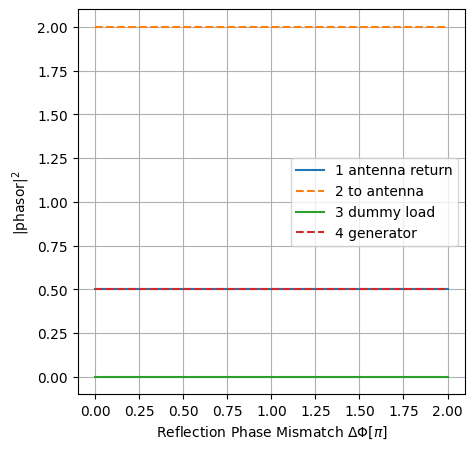

In [190]:
fig, ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(phi_array/np.pi, np.abs(R_mismatch)**2, label='1 antenna return')
ax.plot(phi_array/np.pi, np.abs(A_mismatch)**2, label='2 to antenna', linestyle='--')
ax.plot(phi_array/np.pi, np.abs(D_mismatch)**2, label='3 dummy load')
ax.plot(phi_array/np.pi, np.abs(G_mismatch)**2, label='4 generator', linestyle='--')

ax.set_xlabel('Reflection Phase Mismatch' r' $\Delta \Phi [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()
ax.grid()

In [191]:
# look at 1 hybrid with phase shift in port 1 

nominal = np.array([1, 0, 0, 1], dtype='complex').T # collumn vector of two identical input excitations

theta_array = np.linspace(0, 2*np.pi, 100)
R = np.zeros_like(theta_array, dtype='complex')
A = np.zeros_like(theta_array, dtype='complex')
D = np.zeros_like(theta_array, dtype='complex')
G = np.zeros_like(theta_array, dtype='complex')

for i in range(theta_array.shape[0]):
    theta = theta_array[i]
    S = S_mat_90deg_hybrid()
    nominal[3] = 1 * np.exp(1j*theta)
    result = np.matmul(S, nominal)
    R[i] = result[0]
    A[i] = result[1]
    D[i] = result[2]
    G[i] = result[3]

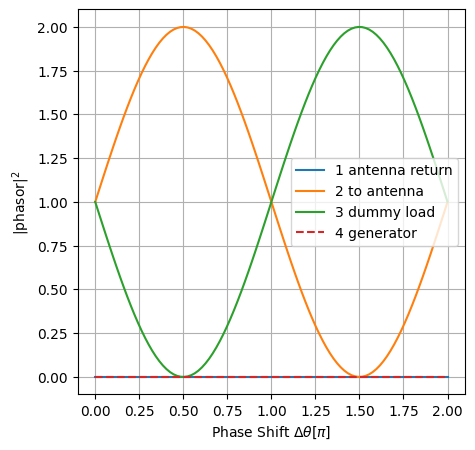

In [192]:
fig, ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(theta_array/np.pi, np.abs(R)**2, label='1 antenna return')
ax.plot(theta_array/np.pi, np.abs(A)**2, label='2 to antenna')
ax.plot(theta_array/np.pi, np.abs(D)**2, label='3 dummy load')
ax.plot(theta_array/np.pi, np.abs(G)**2, label='4 generator', linestyle='--')

ax.set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()
ax.grid()

In [193]:
# mismatch 

nominal = np.array([1, 0, 0, 1], dtype='complex').T # collumn vector of two identical input excitations


theta_array = np.linspace(0, 2*np.pi, 100)
R = np.zeros_like(theta_array, dtype='complex')
A = np.zeros_like(theta_array, dtype='complex')
D = np.zeros_like(theta_array, dtype='complex')
G = np.zeros_like(theta_array, dtype='complex')

for i in range(theta_array.shape[0]):
    theta = theta_array[i]
    S = S_mat_90deg_hybrid()
    nominal[0] = np.exp(1j*theta) # mismatch incoming signal 
    nominal[3] = np.exp(1j*np.pi/2) # phase shifted port 
    result = np.matmul(S, nominal)
    R[i] = result[0]
    A[i] = result[1]
    D[i] = result[2]
    G[i] = result[3]

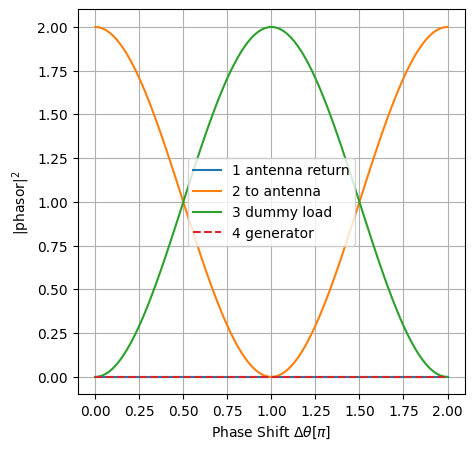

In [194]:
fig, ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(theta_array/np.pi, np.abs(R)**2, label='1 antenna return')
ax.plot(theta_array/np.pi, np.abs(A)**2, label='2 to antenna')
ax.plot(theta_array/np.pi, np.abs(D)**2, label='3 dummy load')
ax.plot(theta_array/np.pi, np.abs(G)**2, label='4 generator', linestyle='--')

ax.set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()
ax.grid()

In [195]:
# now lets build the circuits from scikit-rf. 
# need: two 90 deg hybrids and a phase shifter, and some other componants.  

f = np.array([96]) # not important, assume our componants are chosen for this frequency. 
freq = rf.Frequency.from_f(f, unit='MHz')

# hybrids 
S = S_mat_90deg_hybrid()
s_hybrid = np.zeros((len(f), 4, 4), dtype=complex)
s_hybrid[0, :, :] = S

hybrid1 = rf.Network(frequency=freq, s=s_hybrid, z0=50, name='hybrid 1')
hybrid2 = rf.Network(frequency=freq, s=s_hybrid, z0=50, name='hybrid 2')

# pi/2 phase shifter
S_ps = np.array([[0, 1j], [1j, 0]], dtype='complex') 
s_phase_shifter = np.zeros((len(f), 2, 2), dtype=complex)
s_phase_shifter[0, :, :] = S_ps
phase_shifter = rf.Network(frequency=freq, s=s_phase_shifter, z0=50, name='phase shifter')

print(hybrid1)
print(phase_shifter)

# build the rf network object 

port1 = rf.Circuit.Port(freq, 'port1', z0=50)
port2 = rf.Circuit.Port(freq, 'port2', z0=50)
port3 = rf.Circuit.Port(freq, 'port3', z0=50)
port4 = rf.Circuit.Port(freq, 'port4', z0=50)

# wire together 
connections = [
    [(port1, 0), (hybrid1, 0)],
    [(hybrid2, 1), (port2, 0)],
    [(hybrid2, 2), (port3, 0)],
    [(port4, 0), (hybrid1, 3)],
    [(hybrid1, 1), (hybrid2, 0)],
    [(hybrid1, 2), (phase_shifter, 0)],
    [(phase_shifter, 1), (hybrid2, 3)],
]

cir = rf.Circuit(connections=connections)
ntw = cir.network
print(ntw)


4-Port Network: 'hybrid 1',  96.0-96.0 MHz, 1 pts, z0=[50.+0.j 50.+0.j 50.+0.j 50.+0.j]
2-Port Network: 'phase shifter',  96.0-96.0 MHz, 1 pts, z0=[50.+0.j 50.+0.j]
4-Port Network: '',  96.0-96.0 MHz, 1 pts, z0=[50.+0.j 50.+0.j 50.+0.j 50.+0.j]


In [196]:
f2 = np.array([96, 97, 98, 99]) # not important, assume our componants are chosen for this frequency. 
freq2 = rf.Frequency.from_f(f2, unit='MHz')
print(freq2.f.shape)

(4,)


In [197]:
s_circuit = ntw.s[0,:,:]

print(s_circuit)
print(S_mat(theta=np.pi/2))


np.allclose(s_circuit, S_mat(theta=np.pi/2), rtol=1e-8, atol=1e-8)

# this retuned true, so my matrix derivation is correct. 


[[ 0. +0.j  -0.5+0.5j -0.5+0.5j  0. +0.j ]
 [-0.5+0.5j  0. +0.j   0. +0.j  -0.5+0.5j]
 [-0.5+0.5j  0. +0.j   0. +0.j   0.5-0.5j]
 [ 0. +0.j  -0.5+0.5j  0.5-0.5j  0. +0.j ]]
[[ 0. +0.j  -0.5+0.5j -0.5+0.5j  0. +0.j ]
 [-0.5+0.5j  0. +0.j   0. +0.j  -0.5+0.5j]
 [-0.5+0.5j  0. +0.j   0. +0.j   0.5-0.5j]
 [ 0. +0.j  -0.5+0.5j  0.5-0.5j  0. +0.j ]]


True

In [198]:
row1 = [0, 1j, 1, 0]
row2 = [1j, 0, 0, 1]
row3 = [1, 0, 0, 1j]
row4 = [0, 1, 1j, 0]

S = -np.array([row1, row2, row3, row4])/np.sqrt(2)

AA = 1j
BB = 1
print(np.matmul(S, np.array([[AA, 0, 0, BB]]).T ))
print(np.abs(np.matmul(S, np.array([[AA, 0, 0, BB]]).T )))

[[0.+0.j        ]
 [0.+0.j        ]
 [0.-1.41421356j]
 [0.+0.j        ]]
[[0.        ]
 [0.        ]
 [1.41421356]
 [0.        ]]


In [228]:
# now, lets build your circuit in scikit-rf 

def get_network_90deg_hybrid(freq, z0=50, name='90deg hybrid 1'):
    """
    freq: scikit-rf frequency object
    z0: can be a single value or a list corrisponding to the ports 

    Note: using Pozer hybrid port naming and S matrix definition 
       1 |     |2
       4 |     |3   
    """
    row1 = [0, 1j, 1, 0]
    row2 = [1j, 0, 0, 1]
    row3 = [1, 0, 0, 1j]
    row4 = [0, 1, 1j, 0]

    S = -np.array([row1, row2, row3, row4])/np.sqrt(2)

    s_hybrid = np.zeros((freq.f.shape[0], 4, 4), dtype=complex)
    s_hybrid[0, :, :] = S

    return rf.Network(frequency=freq, s=s_hybrid, z0=z0, name=name)

def get_network_wilkinson_power_divider(freq, z0=50, name='pwrdv 1'):
    row1 = [0, 1j, 1j]
    row2 = [1j, 0, 0]
    row3 = [1j, 0, 0]

    S = -np.array([row1, row2, row3])/np.sqrt(2)

    s_wpd = np.zeros((freq.f.shape[0], 3, 3), dtype=complex)
    s_wpd[0, :, :] = S

    return rf.Network(frequency=freq, s=s_wpd, z0=z0, name=name)

def get_network_phase_shifter(phase_shift, freq, z0=50, name='ps 1'):
    factor = np.exp(1j*phase_shift)
    S_ps = np.array([[0, factor], [factor, 0]], dtype='complex') 
    s_phase_shifter = np.zeros((len(freq.f), 2, 2), dtype=complex)
    s_phase_shifter[0, :, :] = S_ps
    return rf.Network(frequency=freq, s=s_phase_shifter, z0=z0, name=name)

def get_network_series_resistor(freq, R, z0=50, name='resistor 1'):
    factor = 1 / (2*z0 + R)
    S_r = factor*np.array([[R, 2*z0], [2*z0, R]], dtype='complex') 
    s_resistor = np.zeros((len(freq.f), 2, 2), dtype=complex)
    s_resistor[0, :, :] = S_r
    return rf.Network(frequency=freq, s=s_resistor, z0=z0, name=name)

def get_network_matched_lossy_tl(freq, line_freq_hz, z0=50, length_m=1, alpha_db_per_m=0.0, eps_eff=1.0, name='lossy TL'):
    """
    Return a 2x2 S matrix (complex) for a matched (Zc=Z0) lossy TL segment at frequency f_hz.
    - f_hz: scalar frequency in Hz
    - length_m: length in meters
    - alpha_db_per_m: attenuation in dB per meter (power dB/m). Can be 0.
    - eps_eff: effective permittivity (for phase velocity)
    Returns: s (2x2 complex numpy array), gamma (complex propagation constant, Np/m + j rad/m)
    """
    c = 299792458.0
    # convert power dB/m to amplitude Np/m
    # alpha_np = alpha_db_per_m * ln(10) / 40
    alpha_np_per_m = alpha_db_per_m * np.log(10.0) / 40.0

    # phase constant beta
    vph = c / np.sqrt(eps_eff)
    beta = 2.0 * np.pi * line_freq_hz / vph

    gamma = alpha_np_per_m + 1j*beta

    S21 = np.exp(-gamma * length_m)
    S = np.array([[0+0j, S21],
                  [S21,   0+0j]], dtype=complex)
    
    s_line = np.zeros((len(freq.f), 2, 2), dtype=complex)
    s_line[0, :, :] = S
    return rf.Network(frequency=freq, s=s_line, z0=z0, name=name)

def get_network_3port_ant(freq, loss_dB, z0=50, name='lossy 3 port ant'):
    S21 = np.sqrt(10**(-loss_dB/10)/2)
    S = np.array([[0, S21, S21],
                  [S21, 0, 0],
                  [S21, 0, 0]], dtype=complex)
    
    s_3port = np.zeros((len(freq.f), 3, 3), dtype=complex)
    s_3port[0, :, :] = S

    return rf.Network(frequency=freq, s=s_3port, z0=z0, name=name)

def get_network_perfect_three_way_node(freq, z0=50, name='3 way node'):
    a = 1/np.sqrt(2)
    S_3wn = np.array([[-1/3,  2/3,  2/3],
                  [ 2/3, -1/3,  2/3],
                  [ 2/3,  2/3, -1/3]], dtype=complex)
    s_3wn =  np.zeros((len(freq.f), 3, 3), dtype=complex)
    s_3wn[0, :, :] = S_3wn
    return rf.Network(frequency=freq, s=s_3wn, z0=z0, name=name)
    

def get_network_wunit(freq, z0, phase_shifter_phase_shift, return_circuit=False, name='wunit 1'):

    """
    Note: port 1 connects to 90dB Hyb 1 port 1
          port 4 connects to 90dB Hyb 1 port 4
          port 2 connects to 90dB Hyb 2 port 2
          port 3 connects to 90 dBHyb 2 port 3
    """

    # build ports
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)
    port2 = rf.Circuit.Port(freq, f'{name}_port2', z0=z0)
    port3 = rf.Circuit.Port(freq, f'{name}_port3', z0=z0)
    port4 = rf.Circuit.Port(freq, f'{name}_port4', z0=z0)

    # get composite networks 
    hybrid1 = get_network_90deg_hybrid(freq=freq, z0=z0, name=f'{name}_90deg hybrid 1')
    hybrid2 = get_network_90deg_hybrid(freq=freq, z0=z0, name=f'{name}_90deg hybrid 2')
    phase_shifter = get_network_phase_shifter(phase_shift=phase_shifter_phase_shift, freq=freq, z0=z0, name=f'{name}_ps 1')

    # wire together 
    connections = [
        [(port1, 0), (hybrid1, 0)],
        [(hybrid2, 1), (port2, 0)],
        [(hybrid2, 2), (port3, 0)],
        [(port4, 0), (hybrid1, 3)],
        [(hybrid1, 1), (hybrid2, 0)],
        [(hybrid1, 2), (phase_shifter, 0)],
        [(phase_shifter, 1), (hybrid2, 3)],
    ]

    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw
    
def get_network_junit(freq, z0, phase_shifter_phase_shift, return_circuit=False, name='junit 1'):
        """
        Note: port 1 connects to 90dB Hyb port 1
            port 4 connects to phase shifter port 1
            port 2 connects to 90dB Hyb port 2
            port 3 connects to 90 dB Hyb port 3
        """

        # build ports
        port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)
        port2 = rf.Circuit.Port(freq, f'{name}_port2', z0=z0)
        port3 = rf.Circuit.Port(freq, f'{name}_port3', z0=z0)
        port4 = rf.Circuit.Port(freq, f'{name}_port4', z0=z0)

        # get composite networks 
        hybrid = get_network_90deg_hybrid(freq=freq, z0=z0, name=f'{name}_90deg hybrid')
        phase_shifter = get_network_phase_shifter(phase_shift=phase_shifter_phase_shift, freq=freq, z0=z0, name=f'{name}_ps 1')

        # wire together 
        connections = [
            [(port1, 0), (hybrid, 0)],
            [(hybrid, 1), (port2, 0)],
            [(hybrid, 2), (port3, 0)],
            [(hybrid, 3), (phase_shifter, 1)],
            [(phase_shifter, 0), (port4, 0)],
        ]

        cir = rf.Circuit(connections=connections, name=name)
        ntw = cir.network
        if return_circuit:
            return ntw, cir
        else:
            return ntw
        
def get_network_j2unit(freq, z0, phase_shifter_phase_shift, return_circuit=False, name='j2unit 1'):
        """
        Note: port 1 connects to phase shifter port 1
            port 4 connects to 90dB Hyb port 4
            port 2 connects to 90dB Hyb port 2
            port 3 connects to 90 dB Hyb port 3
        """

        # build ports
        port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)
        port2 = rf.Circuit.Port(freq, f'{name}_port2', z0=z0)
        port3 = rf.Circuit.Port(freq, f'{name}_port3', z0=z0)
        port4 = rf.Circuit.Port(freq, f'{name}_port4', z0=z0)

        # get composite networks 
        hybrid = get_network_90deg_hybrid(freq=freq, z0=z0, name=f'{name}_90deg hybrid')
        phase_shifter = get_network_phase_shifter(phase_shift=phase_shifter_phase_shift, freq=freq, z0=z0, name=f'{name}_ps 1')

        # wire together 
        connections = [
            [(port1, 0), (phase_shifter, 0)],
            [(hybrid, 1), (port2, 0)],
            [(hybrid, 2), (port3, 0)],
            [(hybrid, 0), (phase_shifter, 1)],
            [(port4, 0), (hybrid, 3)],
        ]

        cir = rf.Circuit(connections=connections, name=name)
        ntw = cir.network
        if return_circuit:
            return ntw, cir
        else:
            return ntw

def get_circuit_wunit_ring(freq, z0, phase_shifter_phase_shift_array, return_circuit=False, name='wUnitRing1'):
    """
    builds circuit from generator up to TWA out. 4 port device.
    Port 1: to WPD from generator. 
    Port 2: from TWA return 1 to wunit 1 port 1
    Port 3: from TWA return 2 to wunit 2 port 1
    Port 4: from  wunit3 port 2 to TWA antenna 
    """
    # build the wunits
    wunit1 = get_network_wunit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_wunit 1')
    wunit2 = get_network_wunit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[1], return_circuit=False, name=f'{name}_wunit 2')
    wunit3 = get_network_wunit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[2], return_circuit=False, name=f'{name}_wunit 3')
    
    # build Wilkinson power divider 
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')

    # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)
    port2 = rf.Circuit.Port(freq, f'{name}_port2', z0=z0)
    port3 = rf.Circuit.Port(freq, f'{name}_port3', z0=z0)
    port4 = rf.Circuit.Port(freq, f'{name}_port4', z0=z0)

    # dummy load monitor ports to connect to wunits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)
    dummy_load_port3 = rf.Circuit.Port(freq, f'{name}_DL_port3', z0=z0)

    # wire together 
    connections = [
        [(port1,0), (wpd1, 0)],
        [(wpd1,1), (wunit1,3)],
        [(wpd1,2), (wunit2,3)],
        [(port2, 0), (wunit1,0)],
        [(port3, 0), (wunit2,0)],
        [(wunit1,1), (wunit3,0)],
        [(wunit2,1), (wunit3,3)],
        [(port4,0), (wunit3,1)],
        [(dummy_load_port1,0), (wunit1,2)],
        [(dummy_load_port2,0), (wunit2,2)],
        [(dummy_load_port3,0), (wunit3,2)]
    ]

    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw
    
def get_circuit_junit_ring(freq, z0, phase_shifter_phase_shift_array, return_circuit=False, name='wUnitRing1'):
    """
    builds circuit from generator up to TWA out. 4 port device.
    Port 1: to WPD from generator. 
    Port 2: from TWA return 1 to junit 1 port 1
    Port 3: from TWA return 2 to junit 2 port 1
    Port 4: from  junit3 port 2 to TWA antenna 
    """
    # # build the junits
    junit1 = get_network_junit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_junit 1')
    junit2 = get_network_junit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[1], return_circuit=False, name=f'{name}_junit 2')
    junit3 = get_network_junit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[2], return_circuit=False, name=f'{name}_junit 3')
    
    # # build Wilkinson power divider 
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')

    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)
    port2 = rf.Circuit.Port(freq, f'{name}_port2', z0=z0)
    port3 = rf.Circuit.Port(freq, f'{name}_port3', z0=z0)
    port4 = rf.Circuit.Port(freq, f'{name}_port4', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)
    dummy_load_port3 = rf.Circuit.Port(freq, f'{name}_DL_port3', z0=z0)

    # # wire together 
    connections = [
        [(port1,0), (wpd1, 0)],
        [(wpd1,1), (junit1,3)],
        [(wpd1,2), (junit2,3)],
        [(port2, 0), (junit1,0)],
        [(port3, 0), (junit2,0)],
        [(junit1,1), (junit3,0)],
        [(junit2,1), (junit3,3)],
        [(port4,0), (junit3,1)],
        [(dummy_load_port1,0), (junit1,2)],
        [(dummy_load_port2,0), (junit2,2)],
        [(dummy_load_port3,0), (junit3,2)]
    ]

    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw

def get_circuit_j2unit_ring(freq, z0, phase_shifter_phase_shift_array, return_circuit=False, name='wUnitRing1'):
    """
    builds circuit from generator up to TWA out. 4 port device.
    Port 1: to WPD from generator. 
    Port 2: from TWA return 1 to junit 1 port 1
    Port 3: from TWA return 2 to junit 2 port 1
    Port 4: from  junit3 port 2 to TWA antenna 
    """
    # # build the junits
    junit1 = get_network_j2unit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_junit 1')
    junit2 = get_network_j2unit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[1], return_circuit=False, name=f'{name}_junit 2')
    junit3 = get_network_j2unit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[2], return_circuit=False, name=f'{name}_junit 3')
    
    # # build Wilkinson power divider 
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')

    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)
    port2 = rf.Circuit.Port(freq, f'{name}_port2', z0=z0)
    port3 = rf.Circuit.Port(freq, f'{name}_port3', z0=z0)
    port4 = rf.Circuit.Port(freq, f'{name}_port4', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)
    dummy_load_port3 = rf.Circuit.Port(freq, f'{name}_DL_port3', z0=z0)

    # # wire together 
    connections = [
        [(port1,0), (wpd1, 0)],
        [(wpd1,1), (junit1,3)],
        [(wpd1,2), (junit2,3)],
        [(port2, 0), (junit1,0)],
        [(port3, 0), (junit2,0)],
        [(junit1,1), (junit3,0)],
        [(junit2,1), (junit3,3)],
        [(port4,0), (junit3,1)],
        [(dummy_load_port1,0), (junit1,2)],
        [(dummy_load_port2,0), (junit2,2)],
        [(dummy_load_port3,0), (junit3,2)]
    ]

    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw
     
def get_circuit_loaded_junit_ring(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, use_3_way_node=False, name='jUnitRing1'):
    """
    builds circuit from generator up to TWA out. 1 port device, plus 3 dummy loads.
    Port 1: to WPD from generator. 
    use_3_way_node = True replaces the 3-way center fed TWA feed node with a perfect T so scikit-rf can get currents.  
    """
    # # build the junits
    junit1 = get_network_junit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_junit 1')
    junit2 = get_network_junit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[1], return_circuit=False, name=f'{name}_junit 2')
    junit3 = get_network_junit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[2], return_circuit=False, name=f'{name}_junit 3')
    
    # # build Wilkinson power divider 
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')

    # build the antenna load. There are two due to the center fed TWA 
    ant1 = get_network_series_resistor(freq=freq, R=R, z0=z0, name=f'{name}_ant_resistor 1')
    ant2 = get_network_series_resistor(freq=freq, R=R, z0=z0, name=f'{name}_ant_resistor 2')

    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)
    dummy_load_port3 = rf.Circuit.Port(freq, f'{name}_DL_port3', z0=z0)

    # # wire together, using a perfect T in place of the three-way node feedinmg the TWA if requested. 
    if use_3_way_node:
        three_way_node = get_network_perfect_three_way_node(freq=freq, z0=z0, name=f'{name}_3wnode')
        connections = [
            [(port1,0), (wpd1, 0)],
            [(wpd1,1), (junit1,3)],
            [(wpd1,2), (junit2,3)],
            [(ant1, 1), (junit1,0)],
            [(ant2, 1), (junit2,0)],
            [(junit1,1), (junit3,0)],
            [(junit2,1), (junit3,3)],
            [(ant1, 0), (three_way_node, 1)],
            [(ant2, 0), (three_way_node, 2)],
            [(junit3, 1), (three_way_node, 0)],
            [(dummy_load_port1,0), (junit1,2)],
            [(dummy_load_port2,0), (junit2,2)],
            [(dummy_load_port3,0), (junit3,2)]
        ]

    else:
        connections = [
            [(port1,0), (wpd1, 0)],
            [(wpd1,1), (junit1,3)],
            [(wpd1,2), (junit2,3)],
            [(ant1, 1), (junit1,0)],
            [(ant2, 1), (junit2,0)],
            [(junit1,1), (junit3,0)],
            [(junit2,1), (junit3,3)],
            [(ant1,0), (junit3,1), (ant2,0),],
            [(dummy_load_port1,0), (junit1,2)],
            [(dummy_load_port2,0), (junit2,2)],
            [(dummy_load_port3,0), (junit3,2)]
        ]

    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw

def get_circuit_loaded_j2unit_ring(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, use_3_way_node=False, name='j2UnitRing1'):
    """
    builds circuit from generator up to TWA out. 1 port device, plus 3 dummy loads.
    Port 1: to WPD from generator. 
    use_3_way_node = True replaces the 3-way center fed TWA feed node with a perfect T so scikit-rf can get currents.  
    """
    # # build the junits
    junit1 = get_network_j2unit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_junit 1')
    junit2 = get_network_j2unit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[1], return_circuit=False, name=f'{name}_junit 2')
    junit3 = get_network_j2unit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[2], return_circuit=False, name=f'{name}_junit 3')
    
    # # build Wilkinson power divider 
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')

    # build the antenna load. There are two due to the center fed TWA 
    ant1 = get_network_series_resistor(freq=freq, R=R, z0=z0, name=f'{name}_ant_resistor 1')
    ant2 = get_network_series_resistor(freq=freq, R=R, z0=z0, name=f'{name}_ant_resistor 2')

    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)
    dummy_load_port3 = rf.Circuit.Port(freq, f'{name}_DL_port3', z0=z0)

    # # wire together, using a perfect T in place of the three-way node feedinmg the TWA if requested. 
    if use_3_way_node:
        three_way_node = get_network_perfect_three_way_node(freq=freq, z0=z0, name=f'{name}_3wnode')
        connections = [
            [(port1,0), (wpd1, 0)],
            [(wpd1,1), (junit1,3)],
            [(wpd1,2), (junit2,3)],
            [(ant1, 1), (junit1,0)],
            [(ant2, 1), (junit2,0)],
            [(junit1,1), (junit3,0)],
            [(junit2,1), (junit3,3)],
            [(ant1, 0), (three_way_node, 1)],
            [(ant2, 0), (three_way_node, 2)],
            [(junit3, 1), (three_way_node, 0)],
            [(dummy_load_port1,0), (junit1,2)],
            [(dummy_load_port2,0), (junit2,2)],
            [(dummy_load_port3,0), (junit3,2)]
        ]

    else:
        connections = [
            [(port1,0), (wpd1, 0)],
            [(wpd1,1), (junit1,3)],
            [(wpd1,2), (junit2,3)],
            [(ant1, 1), (junit1,0)],
            [(ant2, 1), (junit2,0)],
            [(junit1,1), (junit3,0)],
            [(junit2,1), (junit3,3)],
            [(ant1,0), (junit3,1), (ant2,0),],
            [(dummy_load_port1,0), (junit1,2)],
            [(dummy_load_port2,0), (junit2,2)],
            [(dummy_load_port3,0), (junit3,2)]
        ]

    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw

def get_circuit_loaded_wunit_ring(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, use_3_way_node=False, name='wUnitRing1'):
    """
    builds circuit from generator up to TWA out. 1 port device, plus 3 dummy loads.
    Port 1: to WPD from generator. 
    use_3_way_node = True replaces the 3-way center fed TWA feed node with a perfect T so scikit-rf can get currents.  
    """
    # # build the junits
    junit1 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_junit 1')
    junit2 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[1], return_circuit=False, name=f'{name}_junit 2')
    junit3 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[2], return_circuit=False, name=f'{name}_junit 3')
    
    # # build Wilkinson power divider 
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')

    # build the antenna load. There are two due to the center fed TWA 
    ant1 = get_network_series_resistor(freq=freq, R=R, z0=z0, name=f'{name}_ant_resistor 1')
    ant2 = get_network_series_resistor(freq=freq, R=R, z0=z0, name=f'{name}_ant_resistor 2')

    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)
    dummy_load_port3 = rf.Circuit.Port(freq, f'{name}_DL_port3', z0=z0)

    # # wire together, using a perfect T in place of the three-way node feedinmg the TWA if requested. 
    if use_3_way_node:
        three_way_node = get_network_perfect_three_way_node(freq=freq, z0=z0, name=f'{name}_3wnode')
        connections = [
            [(port1,0), (wpd1, 0)],
            [(wpd1,1), (junit1,3)],
            [(wpd1,2), (junit2,3)],
            [(ant1, 1), (junit1,0)],
            [(ant2, 1), (junit2,0)],
            [(junit1,1), (junit3,0)],
            [(junit2,1), (junit3,3)],
            [(ant1, 0), (three_way_node, 1)],
            [(ant2, 0), (three_way_node, 2)],
            [(junit3, 1), (three_way_node, 0)],
            [(dummy_load_port1,0), (junit1,2)],
            [(dummy_load_port2,0), (junit2,2)],
            [(dummy_load_port3,0), (junit3,2)]
        ]

    else:
        connections = [
            [(port1,0), (wpd1, 0)],
            [(wpd1,1), (junit1,3)],
            [(wpd1,2), (junit2,3)],
            [(ant1, 1), (junit1,0)],
            [(ant2, 1), (junit2,0)],
            [(junit1,1), (junit3,0)],
            [(junit2,1), (junit3,3)],
            [(ant1,0), (junit3,1), (ant2,0),],
            [(dummy_load_port1,0), (junit1,2)],
            [(dummy_load_port2,0), (junit2,2)],
            [(dummy_load_port3,0), (junit3,2)]
        ]

    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw

def get_circuit_loaded_wunit2wpd2_ring(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, use_3_way_node=False, name='wUnitRing1'):
    """
    builds circuit from generator up to TWA out. 1 port device, plus 2 dummy loads.
    Port 1: to WPD from generator. 
    use_3_way_node = True replaces the 3-way center fed TWA feed node with a perfect T so scikit-rf can get currents.  
    """
    # # build the junits
    wunit1 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_wunit 1')
    wunit2 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[1], return_circuit=False, name=f'{name}_wunit 2')
    phase_shifter = get_network_phase_shifter(phase_shift=phase_shifter_phase_shift_array[2], freq=freq, z0=z0, name=f'{name}_ps 1')
    
    # # build Wilkinson power divider 
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')
    wpd2 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 2')

    # build the antenna load. There are two due to the center fed TWA 
    ant1 = get_network_matched_lossy_tl(freq, line_freq_hz=96e6, z0=50, length_m=1, alpha_db_per_m=R, eps_eff=1.0, name=f'{name}lossy TL 1')
    ant2 = get_network_matched_lossy_tl(freq, line_freq_hz=96e6, z0=50, length_m=1, alpha_db_per_m=R, eps_eff=1.0, name=f'{name}lossy TL 2')

    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)

    # # wire together, using a perfect T in place of the three-way node feedinmg the TWA if requested. 
    if use_3_way_node:
        three_way_node = get_network_perfect_three_way_node(freq=freq, z0=z0, name=f'{name}_3wnode')
        connections = [
            [(port1,0), (wpd1, 0)],
            [(wpd1,1), (wunit1,3)],
            [(wpd1,2), (wunit2,3)],
            [(ant1, 1), (wunit1,0)],
            [(ant2, 1), (wunit2,0)],
            [(wunit1,1), (wpd2,1)],
            [(wunit2,1), (wpd2,2)],
            [(ant1, 0), (three_way_node, 1)],
            [(ant2, 0), (three_way_node, 2)],
            [(phase_shifter, 1), (three_way_node, 0)],
            [(phase_shifter, 0), (wpd2, 0)],
            [(dummy_load_port1,0), (wunit1,2)],
            [(dummy_load_port2,0), (wunit2,2)],
        ]

    else:
        connections = [
            [(port1,0), (wpd1, 0)],
            [(wpd1,1), (wunit1,3)],
            [(wpd1,2), (wunit2,3)],
            [(ant1, 1), (wunit1,0)],
            [(ant2, 1), (wunit2,0)],
            [(wunit1,1), (wpd2,1)],
            [(wunit2,1), (wpd2,2)],
            [(ant1, 0), (ant2, 0), (phase_shifter, 1)],
            [(phase_shifter, 0), (wpd2, 0)],
            [(dummy_load_port1,0), (wunit1,2)],
            [(dummy_load_port2,0), (wunit2,2)],
        ]

    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw
    
def get_circuit_wunit2wpd2_ring(freq, z0, phase_shifter_phase_shift_array, return_circuit=False, name='wUnitRing1'):
    """
    builds circuit from generator up to TWA out. 4 port device, plus 2 dummy loads.
    Port 1: to WPD from generator. 
    use_3_way_node = True replaces the 3-way center fed TWA feed node with a perfect T so scikit-rf can get currents.  
    """
    # # build the junits
    wunit1 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_wunit 1')
    wunit2 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[1], return_circuit=False, name=f'{name}_wunit 2')
    phase_shifter = get_network_phase_shifter(phase_shift=phase_shifter_phase_shift_array[2], freq=freq, z0=z0, name=f'{name}_ps 1')
    
    # # build Wilkinson power divider 
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')
    wpd2 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 2')

    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)
    port2 = rf.Circuit.Port(freq, f'{name}_port2', z0=z0)
    port3 = rf.Circuit.Port(freq, f'{name}_port3', z0=z0)
    port4 = rf.Circuit.Port(freq, f'{name}_port4', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)

    connections = [
        [(port1,0), (wpd1, 0)],
        [(wpd1,1), (wunit1,3)],
        [(wpd1,2), (wunit2,3)],
        [(port2, 0), (wunit1,0)],
        [(port3, 0), (wunit2,0)],
        [(wunit1,1), (wpd2,1)],
        [(wunit2,1), (wpd2,2)],
        [(phase_shifter, 1), (port4, 0)],
        [(phase_shifter, 0), (wpd2, 0)],
        [(dummy_load_port1,0), (wunit1,2)],
        [(dummy_load_port2,0), (wunit2,2)],
    ]
    
    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw


def get_circuit_loaded_wunit2wpd2_ring_1ant(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, name='wunit 3 port ant'):
    """
    builds circuit from generator up to TWA out. 1 port device, plus 2 dummy loads.
    Port 1: to WPD from generator. 
    use_3_way_node = True replaces the 3-way center fed TWA feed node with a perfect T so scikit-rf can get currents.  
    """
    # # build the junits
    wunit1 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_wunit 1')
    wunit2 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[1], return_circuit=False, name=f'{name}_wunit 2')
    phase_shifter = get_network_phase_shifter(phase_shift=phase_shifter_phase_shift_array[2], freq=freq, z0=z0, name=f'{name}_ps 1')
    
    # # build Wilkinson power divider 
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')
    wpd2 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 2')

    # build the antenna load. There are two due to the center fed TWA 
    ant = get_network_3port_ant(freq, loss_dB=R, z0=50, name=f'{name}lossy 3 port ant')

    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)

    # # wire together, using a perfect T in place of the three-way node feedinmg the TWA if requested. 


    connections = [
        [(port1,0), (wpd1, 0)],
        [(wpd1,1), (wunit1,3)],
        [(wpd1,2), (wunit2,3)],
        [(ant, 1), (wunit1,0)],
        [(ant, 2), (wunit2,0)],
        [(wunit1,1), (wpd2,1)],
        [(wunit2,1), (wpd2,2)],
        [(phase_shifter, 1), (ant, 0)],
        [(phase_shifter, 0), (wpd2, 0)],
        [(dummy_load_port1,0), (wunit1,2)],
        [(dummy_load_port2,0), (wunit2,2)],
    ]

    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw
    
def get_circuit_loaded_simple_TWA_wunit_ring(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, use_3_way_node=False, name='wUnitRing1'):
    """
    builds circuit from generator up to TWA out. 1 port device, plus 2 dummy loads.
    Port 1: to WPD from generator. 
    use_3_way_node = True replaces the 3-way center fed TWA feed node with a perfect T so scikit-rf can get currents.  
    """
    # # build the wunits
    wunit1 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_wunit 1')

    phase_shifter = get_network_phase_shifter(phase_shift=phase_shifter_phase_shift_array[1], freq=freq, z0=z0, name=f'{name}_ps 1')
    

    # build the antenna load. There are two due to the center fed TWA 
    ant1 = get_network_matched_lossy_tl(freq, line_freq_hz=96e6, z0=50, length_m=1, alpha_db_per_m=R, eps_eff=1.0, name=f'{name}lossy TL 1')
    

    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)

    # build connections 
    connections = [
        [(port1,0), (wunit1, 3)],
        [(ant1, 1), (wunit1, 0)],
        [(dummy_load_port1, 0), (wunit1, 2)],
        [(phase_shifter, 0), (wunit1, 1)],
        [(phase_shifter, 1), (ant1, 0)]

    ]
    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw
    
def get_circuit_loaded_2wunit_isolated_rings(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, name='wUnitIsorings'):
    """
    builds circuit from generator up to TWA out. 1 port device, plus 2 dummy loads.
    Port 1: to WPD from generator. 
    use_3_way_node = True replaces the 3-way center fed TWA feed node with a perfect T so scikit-rf can get currents.  
    """
    # # build the wunits
    wunit1 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_wunit 1')
    wunit2 = get_network_wunit(freq=freq, z0=z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_wunit 2')
    phase_shifter1 = get_network_phase_shifter(phase_shift=phase_shifter_phase_shift_array[1], freq=freq, z0=z0, name=f'{name}_ps 1')
    phase_shifter2 = get_network_phase_shifter(phase_shift=phase_shifter_phase_shift_array[1], freq=freq, z0=z0, name=f'{name}_ps 2')

    # build the antenna load. There are two due to the center fed TWA 
    ant1 = get_network_matched_lossy_tl(freq, line_freq_hz=96e6, z0=50, length_m=1, alpha_db_per_m=R, eps_eff=1.0, name=f'{name}lossy TL 1')
    ant2 = get_network_matched_lossy_tl(freq, line_freq_hz=96e6, z0=50, length_m=1, alpha_db_per_m=R, eps_eff=1.0, name=f'{name}lossy TL 2')
    
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')
    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)

    # build connections 
    connections = [
        [(port1,0), (wpd1, 0)],
        [(wpd1, 1), (wunit1, 3)],
        [(wpd1,2), (wunit2, 3)],
        [(wunit1,1), (phase_shifter1, 0)],
        [(wunit2,1), (phase_shifter2, 0)],
        [(wunit1,2), (dummy_load_port1, 0)],
        [(wunit2,2), (dummy_load_port2, 0)],
        [(ant1, 1), (wunit1, 0)],
        [(ant2, 1), (wunit2, 0)],
        [(phase_shifter1, 1), (ant1,0)],
        [(phase_shifter2, 1), (ant2,0)]
    ]
    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw

def branch_currents(circuit, power, phase):
    """
    Returns the per-branch currents (complex phasors) from a scikit-rf Circuit.
    Magnitude is in Amps (peak), sign convention: positive means
    current entering first component in the connection tuple.
    """
    I_all = circuit.currents(power, phase)  # shape: (n_freqs, 2*N_connections)
    n_freqs, n_cols = I_all.shape
    n_connections = n_cols // 2

    # Take only the first entry of each pair (branch current into first port)
    I_branch = I_all[:, 0::2]

    # Optional: sanity check — ensure I_first ≈ -I_second for each branch
    for k in range(n_connections):
        diff = I_all[:, 2*k] + I_all[:, 2*k + 1]
        if np.max(np.abs(diff)) > 1e-6:
            print(f"Warning: branch {k} currents not equal and opposite")

    return I_branch

def branch_voltages(circuit, power, phase):
    """
    Returns the per-branch voltages (complex phasors) from a scikit-rf Circuit.
    Magnitude is in volts (peak)
    """
    V_all = circuit.voltages(power, phase)  # shape: (n_freqs, 2*N_connections)
    n_freqs, n_cols = V_all.shape
    n_connections = n_cols // 2

    # Take only the first entry of each pair (branch voltage into first port)
    V_branch = V_all[:, 0::2]

    # Optional: sanity check — ensure I_first ≈ -I_second for each branch
    # for k in range(n_connections):
    #     diff = V_all[:, 2*k] + V_all[:, 2*k + 1]
    #     if np.max(np.abs(diff)) > 1e-6:
    #         print(f"Warning: branch {k} currents not equal and opposite")

    return V_branch

def branch_powers(circuit, power, phase):
    currents = branch_currents(circuit, power, phase)
    voltages = branch_voltages(circuit, power, phase)

    powers = 0.5*np.real(voltages * np.conj(currents))

    return powers

    
def get_circuit_junit_ring_2(freq, z0, phase_shifter_phase_shift_array, return_circuit=False, name='wUnitRing1'):
    """
    builds circuit from generator up to TWA out. 4 port device. This time, the third j-unit has no phase shifter. 
    Port 1: to WPD from generator. 
    Port 2: from TWA return 1 to junit 1 port 1
    Port 3: from TWA return 2 to junit 2 port 1
    Port 4: from  90deg hybrid3 port 2 to TWA antenna 
    """
    # # build the junits
    junit1 = get_network_junit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[0], return_circuit=False, name=f'{name}_junit 1')
    junit2 = get_network_junit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[1], return_circuit=False, name=f'{name}_junit 2')
    #junit3 = get_network_junit(freq, z0, phase_shifter_phase_shift=phase_shifter_phase_shift_array[2], return_circuit=False, name=f'{name}_junit 3')
    hybrid3 = get_network_90deg_hybrid(freq, z0, name=f'{name}_90deg hybrid3')

    # # build Wilkinson power divider 
    wpd1 =  get_network_wilkinson_power_divider(freq, z0=z0, name=f'{name}wpwrdv 1')

    # # build ports 
    port1 = rf.Circuit.Port(freq, f'{name}_port1', z0=z0)
    port2 = rf.Circuit.Port(freq, f'{name}_port2', z0=z0)
    port3 = rf.Circuit.Port(freq, f'{name}_port3', z0=z0)
    port4 = rf.Circuit.Port(freq, f'{name}_port4', z0=z0)

    # # dummy load monitor ports to connect to junits
    dummy_load_port1 = rf.Circuit.Port(freq, f'{name}_DL_port1', z0=z0)
    dummy_load_port2 = rf.Circuit.Port(freq, f'{name}_DL_port2', z0=z0)
    dummy_load_port3 = rf.Circuit.Port(freq, f'{name}_DL_port3', z0=z0)

    # # wire together 
    connections = [
        [(port1,0), (wpd1, 0)],
        [(wpd1,1), (junit1,3)],
        [(wpd1,2), (junit2,3)],
        [(port2, 0), (junit1,0)],
        [(port3, 0), (junit2,0)],
        [(junit1,1), (hybrid3,0)],
        [(junit2,1), (hybrid3,3)],
        [(port4,0), (hybrid3,1)],
        [(dummy_load_port1,0), (junit1,2)],
        [(dummy_load_port2,0), (junit2,2)],
        [(dummy_load_port3,0), (hybrid3,2)]
    ]

    cir = rf.Circuit(connections=connections, name=name)
    ntw = cir.network
    if return_circuit:
        return ntw, cir
    else:
        return ntw
    

In [200]:
# test the wunit
f = np.array([96]) # not important, assume our componants are chosen for this frequency. 
freq = rf.Frequency.from_f(f, unit='MHz')
excitation = np.array([[1,0,0,1]]).T
phase_shift = np.pi/2

wunit_network = get_network_wunit(freq, z0=50, phase_shifter_phase_shift=phase_shift, return_circuit=False, name='wunit 1')

# test junit 
junit_network = get_network_wunit(freq, z0=50, phase_shifter_phase_shift=phase_shift, return_circuit=False, name='junit 1')
print(wunit_network.s*2)

print(junit_network.s*2)
print(len(freq.f))

[[[ 0.+0.j -1.+1.j -1.+1.j  0.+0.j]
  [-1.+1.j  0.+0.j  0.+0.j -1.+1.j]
  [-1.+1.j  0.+0.j  0.+0.j  1.-1.j]
  [ 0.+0.j -1.+1.j  1.-1.j  0.+0.j]]]
[[[ 0.+0.j -1.+1.j -1.+1.j  0.+0.j]
  [-1.+1.j  0.+0.j  0.+0.j -1.+1.j]
  [-1.+1.j  0.+0.j  0.+0.j  1.-1.j]
  [ 0.+0.j -1.+1.j  1.-1.j  0.+0.j]]]
1


In [201]:
# test out wunit circuit model 

phase = [np.pi/2, np.pi/2, np.pi/2]

phase_mismatch_array = np.linspace(0, 2*np.pi, 400)
dphi = 0#np.pi/5
twa_return1_power_factor = 0.9
twa_return2_power_factor = 0.8

# response arrays for plotting 
generator_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_return1_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_return2_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_out_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)

dummy_load1_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
dummy_load2_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
dummy_load3_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)



wunit_ring_network = get_circuit_wunit_ring(freq, z0=50, phase_shifter_phase_shift_array=phase, return_circuit=False, name='wUnitRing1')
s_wunit_ring_network = wunit_ring_network.s[0,:,:]


for i in range(phase_mismatch_array.shape[0]):
    # excite the generator and a matching phase mismatch for the two antenna returns
    # note the WPD sets the generator phase back by 90 deg for the two WPD outputs,
    # so to scan with idential inputs returning from TWA, need initial -90 deg 
    excitation = np.array([1,
                           (twa_return1_power_factor*1/np.sqrt(2))*np.exp(-1j*np.pi/2)*np.exp(1j*phase_mismatch_array[i]),
                           (twa_return2_power_factor*1/np.sqrt(2))*np.exp(-1j*np.pi/2)*np.exp(1j*(phase_mismatch_array[i] + dphi)),
                           0,
                           0,
                           0,
                           0]).T
    
    result = np.matmul(s_wunit_ring_network, excitation)
    generator_phasor_array[i] = result[0]
    twa_return1_phasor_array[i] = result[1]
    twa_return2_phasor_array[i] = result[2]
    twa_out_phasor_array[i] = result[3]

    dummy_load1_phasor_array[i] = result[4]
    dummy_load2_phasor_array[i] = result[5]
    dummy_load3_phasor_array[i] = result[6]



Text(0.5, 1.0, 'Name: wUnitRing1\ndphi: 0.000 degrees\nTWA return power factor 1,2: 0.90, 0.80')

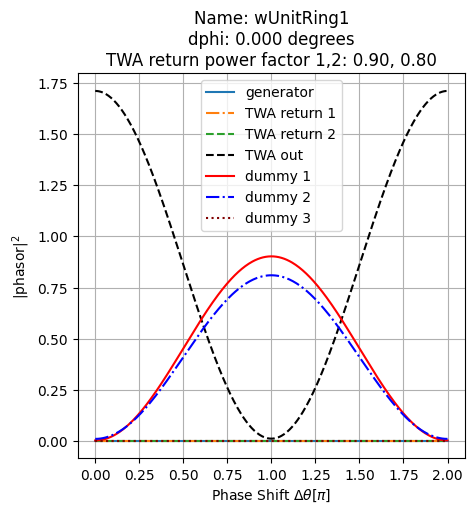

In [202]:
# plot 
fig, ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(phase_mismatch_array/np.pi, np.abs(generator_phasor_array)**2, label='generator')
ax.plot(phase_mismatch_array/np.pi, np.abs(twa_return1_phasor_array)**2, label='TWA return 1', linestyle='-.')
ax.plot(phase_mismatch_array/np.pi, np.abs(twa_return2_phasor_array)**2, label='TWA return 2', linestyle='--')
ax.plot(phase_mismatch_array/np.pi, np.abs(twa_out_phasor_array)**2, label='TWA out', linestyle='--', color='black')

ax.plot(phase_mismatch_array/np.pi, np.abs(dummy_load1_phasor_array)**2, label='dummy 1', linestyle='solid', color='red')
ax.plot(phase_mismatch_array/np.pi, np.abs(dummy_load2_phasor_array)**2, label='dummy 2', linestyle='-.', color='blue')
ax.plot(phase_mismatch_array/np.pi, np.abs(dummy_load3_phasor_array)**2, label='dummy 3', linestyle=':', color='maroon')


ax.set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()
ax.grid()
title_string = f'{wunit_ring_network.name}\n' \
    + f'dphi: {dphi*180/np.pi:.3f} degrees\n' \
    + f'TWA return power factor 1,2: {twa_return1_power_factor:.2f}, {twa_return2_power_factor:.2f}'
ax.set_title(f'Name: {title_string}')

In [203]:
# test out wunit2wpd2 unit circuit model 

# test out wunit circuit model 

phase = [np.pi/2, np.pi/2, np.pi/2]

phase_mismatch_array = np.linspace(0, 2*np.pi, 400)
dphi = 0#np.pi/5
twa_return1_power_factor = 10
twa_return2_power_factor = 10

# response arrays for plotting 
generator_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_return1_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_return2_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_out_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)

dummy_load1_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
dummy_load2_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)





for i in range(phase_mismatch_array.shape[0]):
    phase = [phase_mismatch_array[i], phase_mismatch_array[i], np.pi/2]
    wunit_ring_network = get_circuit_wunit2wpd2_ring(freq, z0=50, phase_shifter_phase_shift_array=phase, return_circuit=False, name='wUnitRing1')
    s_wunit_ring_network = wunit_ring_network.s[0,:,:]
    # excite the generator and a matching phase mismatch for the two antenna returns
    # note the WPD sets the generator phase back by 90 deg for the two WPD outputs,
    # so to scan with idential inputs returning from TWA, need initial -90 deg 
    excitation = np.array([1,
                           (twa_return1_power_factor*1/np.sqrt(2))*np.exp(-1j*np.pi/2),
                           (twa_return2_power_factor*1/np.sqrt(2))*np.exp(-1j*np.pi/2),
                           0,
                           0,
                           0]).T
    
    result = np.matmul(s_wunit_ring_network, excitation)
    generator_phasor_array[i] = result[0]
    twa_return1_phasor_array[i] = result[1]
    twa_return2_phasor_array[i] = result[2]
    twa_out_phasor_array[i] = result[3]

    dummy_load1_phasor_array[i] = result[4]
    dummy_load2_phasor_array[i] = result[5]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


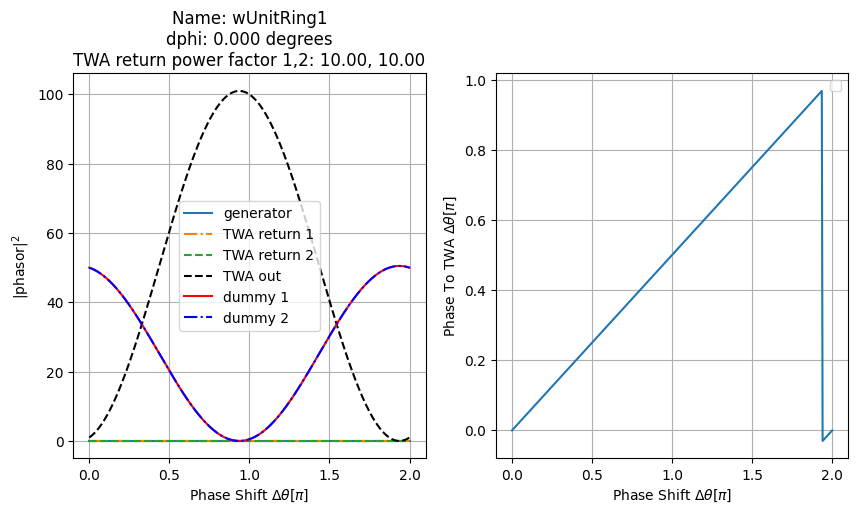

In [204]:
# plot 
fig, ax = plt.subplots(1,2,figsize=(10,5))

ax[0].plot(phase_mismatch_array/np.pi, np.abs(generator_phasor_array)**2, label='generator')
ax[0].plot(phase_mismatch_array/np.pi, np.abs(twa_return1_phasor_array)**2, label='TWA return 1', linestyle='-.')
ax[0].plot(phase_mismatch_array/np.pi, np.abs(twa_return2_phasor_array)**2, label='TWA return 2', linestyle='--')
ax[0].plot(phase_mismatch_array/np.pi, np.abs(twa_out_phasor_array)**2, label='TWA out', linestyle='--', color='black')

ax[0].plot(phase_mismatch_array/np.pi, np.abs(dummy_load1_phasor_array)**2, label='dummy 1', linestyle='solid', color='red')
ax[0].plot(phase_mismatch_array/np.pi, np.abs(dummy_load2_phasor_array)**2, label='dummy 2', linestyle='-.', color='blue')
# ax[0].plot(phase_mismatch_array/np.pi, np.abs(dummy_load3_phasor_array)**2, label='dummy 3', linestyle=':', color='maroon')


ax[0].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[0].set_ylabel(r'|phasor|$^2$')
ax[0].legend()
ax[0].grid()
title_string = f'{wunit_ring_network.name}\n' \
    + f'dphi: {dphi*180/np.pi:.3f} degrees\n' \
    + f'TWA return power factor 1,2: {twa_return1_power_factor:.2f}, {twa_return2_power_factor:.2f}'
ax[0].set_title(f'Name: {title_string}')


# plot phases 
ax[1].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[1].set_ylabel('Phase To TWA' r' $\Delta \theta [\pi$]')
ax[1].legend()
ax[1].grid()
ax[1].plot(phase_mismatch_array/np.pi,  np.arctan2(np.imag(twa_out_phasor_array), np.real(twa_out_phasor_array))/np.pi)

In [205]:
# test out junit circuit model 

phase = [3*np.pi/2, 3*np.pi/2, 3*np.pi/2]

phase_mismatch_array = np.linspace(0, 2*np.pi, 400)
# dphi = 0
# twa_return1_power_factor = 1
# twa_return2_power_factor = 1

# response arrays for plotting 
generator_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_return1_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_return2_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_out_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)

dummy_load1_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
dummy_load2_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
dummy_load3_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)



junit_ring_network = get_circuit_j2unit_ring(freq, z0=50, phase_shifter_phase_shift_array=phase, return_circuit=False, name='jUnitRing1')
s_junit_ring_network = junit_ring_network.s[0,:,:]


for i in range(phase_mismatch_array.shape[0]):
    # excite the generator and a matching phase mismatch for the two antenna returns
    # note the WPD sets the generator phase back by 90 deg for the two WPD outputs,
    # so to scan with idential inputs returning from TWA, need initial -90 deg 
    excitation = np.array([1,
                           (twa_return1_power_factor*1/np.sqrt(2))*np.exp(-1j*np.pi/2)*np.exp(1j*phase_mismatch_array[i]),
                           (twa_return2_power_factor*1/np.sqrt(2))*np.exp(-1j*np.pi/2)*np.exp(1j*(phase_mismatch_array[i] + dphi)),
                           0,
                           0,
                           0,
                           0]).T
    
    result = np.matmul(s_junit_ring_network, excitation)
    generator_phasor_array[i] = result[0]
    twa_return1_phasor_array[i] = result[1]
    twa_return2_phasor_array[i] = result[2]
    twa_out_phasor_array[i] = result[3]

    dummy_load1_phasor_array[i] = result[4]
    dummy_load2_phasor_array[i] = result[5]
    dummy_load3_phasor_array[i] = result[6]

Text(0.5, 1.0, 'Name: jUnitRing1\ndphi: 0.000 degrees\nTWA return power factor 1,2: 10.00, 10.00')

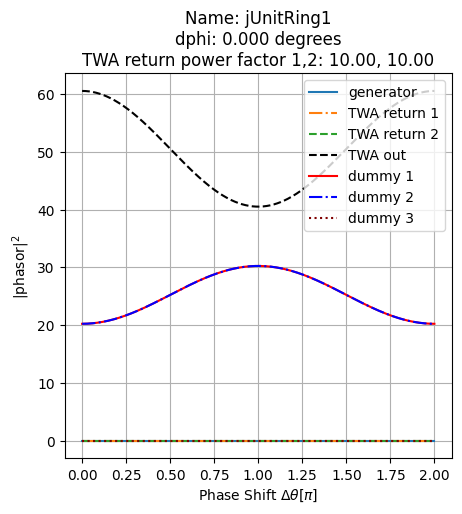

In [206]:
# plot 
fig, ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(phase_mismatch_array/np.pi, np.abs(generator_phasor_array)**2, label='generator')
ax.plot(phase_mismatch_array/np.pi, np.abs(twa_return1_phasor_array)**2, label='TWA return 1', linestyle='-.')
ax.plot(phase_mismatch_array/np.pi, np.abs(twa_return2_phasor_array)**2, label='TWA return 2', linestyle='--')
ax.plot(phase_mismatch_array/np.pi, np.abs(twa_out_phasor_array)**2, label='TWA out', linestyle='--', color='black')

ax.plot(phase_mismatch_array/np.pi, np.abs(dummy_load1_phasor_array)**2, label='dummy 1', linestyle='solid', color='red')
ax.plot(phase_mismatch_array/np.pi, np.abs(dummy_load2_phasor_array)**2, label='dummy 2', linestyle='-.', color='blue')
ax.plot(phase_mismatch_array/np.pi, np.abs(dummy_load3_phasor_array)**2, label='dummy 3', linestyle=':', color='maroon')


ax.set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()
ax.grid()
title_string = f'{junit_ring_network.name}\n' \
    + f'dphi: {dphi*180/np.pi:.3f} degrees\n' \
    + f'TWA return power factor 1,2: {twa_return1_power_factor:.2f}, {twa_return2_power_factor:.2f}'
ax.set_title(f'Name: {title_string}')

In [207]:
# test the antenna loaded model 
#get_circuit_loaded_junit_ring(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, name='wUnitRing1')

antload = 1 # ohm, keep < z0 = 50 for small loading 
use_3_way_node = False
# test out loaded junit circuit model 

#phase = [np.pi/2, np.pi/2, np.pi/2]

phase_array = np.linspace(0, 2*np.pi, 400)
# dphi = 0
# twa_return1_power_factor = 1
# twa_return2_power_factor = 1

# response arrays for plotting 
generator_phasor_array = np.zeros_like(phase_array, dtype=complex)


dummy_load1_phasor_array = np.zeros_like(phase_array, dtype=complex)
dummy_load2_phasor_array = np.zeros_like(phase_array, dtype=complex)
dummy_load3_phasor_array = np.zeros_like(phase_array, dtype=complex)

# make other storage arrays for internal powers within antenna ring network 

int_generator_phasor_array_0 = np.zeros_like(phase_array)
wpd_out_phasor_array_1 = np.zeros_like(phase_array)
wpd_out_phasor_array_2 = np.zeros_like(phase_array)
twa_return_phasor_array_3 = np.zeros_like(phase_array)
twa_return_phasor_array_4 = np.zeros_like(phase_array)
twa_split_power_phasor_array_7 = np.zeros_like(phase_array)
twa_split_power_phasor_array_8 = np.zeros_like(phase_array)
twa_infeed_phasor_array_9 = np.zeros_like(phase_array)

# junit_ring_network = get_circuit_junit_ring(freq, z0=50, phase_shifter_phase_shift_array=phase, return_circuit=False, name='jUnitRing1')
# s_junit_ring_network = junit_ring_network.s[0,:,:]


for i in range(phase_array.shape[0]):
    # grab the loaded j unit ring s matrix for the given phase shiftor phase. Allow the ring to set up the resonance correctly 
    loaded_j, loaded_j_circ = get_circuit_loaded_j2unit_ring(freq, z0=50, phase_shifter_phase_shift_array=[np.pi/2, np.pi/2, phase_array[i]], R=antload, return_circuit=True, use_3_way_node=use_3_way_node, name='j2UnitRingLoaded')
    s_loaded_j_unit_ring_network = loaded_j.s[0,:,:]
    excitation = np.array([1,
                           0,
                           0,
                           0]).T
    
    result = np.matmul(s_loaded_j_unit_ring_network, excitation)
    generator_phasor_array[i] = result[0]
    dummy_load1_phasor_array[i] = result[1]
    dummy_load2_phasor_array[i] = result[2]
    dummy_load3_phasor_array[i] = result[3]

    # now, probe the powers in the internal ports. 
    if use_3_way_node:
        currents = branch_currents(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
        voltages = branch_voltages(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
        powers = branch_powers(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
        
        # load up the power vectors 
        int_generator_phasor_array_0[i] = np.abs(powers[0][0])
        wpd_out_phasor_array_1[i] = np.abs(powers[0][1])
        wpd_out_phasor_array_2[i] = np.abs(powers[0][2])
        twa_return_phasor_array_3[i] = np.abs(powers[0][3])
        twa_return_phasor_array_4[i] = np.abs(powers[0][4])
        twa_split_power_phasor_array_7[i] = np.abs(powers[0][7])
        twa_split_power_phasor_array_8[i] = np.abs(powers[0][8])
        twa_infeed_phasor_array_9[i] = np.abs(powers[0][9])
        #print(powers)
    # currents = loaded_j_circ.currents(power=excitation, phase=excitation*0)
    #print(currents)
    #print(voltages)
    #print(loaded_j_circ.voltages(excitation, excitation*0))
    # print(currents.shape)
    # print(voltages.shape)
    # print(powers)
    # print(np.abs(powers))



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 1.0, 'Name: j2UnitRingLoaded\n antenna load: 1 Ohms per half\n use_3_way_node: False')

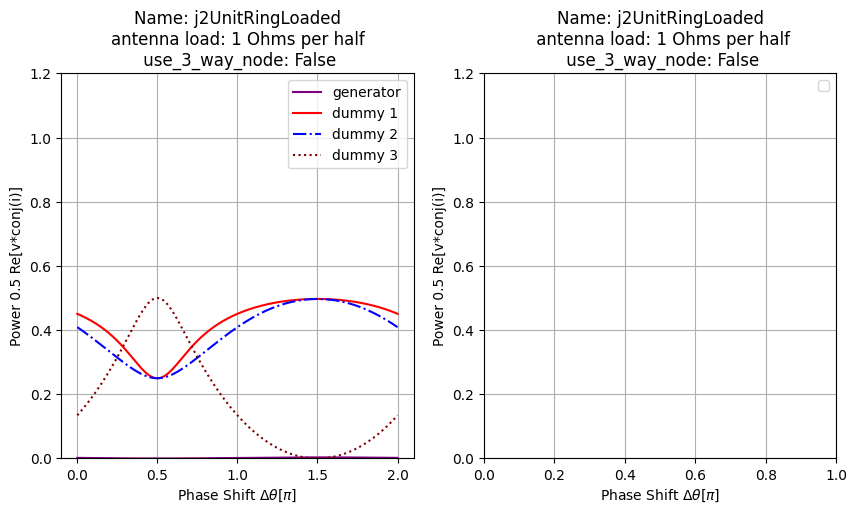

In [208]:
# plot 
fig, ax = plt.subplots(1,2,figsize=(10,5))

ax[0].plot(phase_array/np.pi, np.abs(generator_phasor_array)**2, label='generator', color='purple')

if use_3_way_node:
    ax[0].plot(phase_array/np.pi, int_generator_phasor_array_0, label='0: to wpd',color='green', linestyle='--')
    ax[0].plot(phase_array/np.pi, wpd_out_phasor_array_1, label='1: wpd out',color='orange', linestyle='solid')
    ax[0].plot(phase_array/np.pi, wpd_out_phasor_array_2, label='2: wpd out',color='darkred', linestyle='--')
    ax[0].plot(phase_array/np.pi, twa_infeed_phasor_array_9, label='9: twa in',color='pink', linestyle='--')

# plot the circulating power on the other axis
if use_3_way_node:
    ax[1].plot(phase_array/np.pi, twa_infeed_phasor_array_9, label='9: twa in',color='pink', linestyle='--') 
    ax[1].plot(phase_array/np.pi, twa_return_phasor_array_3, label='3: twa return',color='black')
    ax[1].plot(phase_array/np.pi, twa_return_phasor_array_4, label='4: twa return',color='orange', linestyle='--')
    ax[1].plot(phase_array/np.pi, twa_split_power_phasor_array_7, label='7: twa left',color='red', linestyle='-.')
    ax[1].plot(phase_array/np.pi, twa_split_power_phasor_array_8, label='8: twa right',color='yellow', linestyle=':')

ax[0].plot(phase_array/np.pi, np.abs(dummy_load1_phasor_array)**2, label='dummy 1', linestyle='solid', color='red')
ax[0].plot(phase_array/np.pi, np.abs(dummy_load2_phasor_array)**2, label='dummy 2', linestyle='-.', color='blue')
ax[0].plot(phase_array/np.pi, np.abs(dummy_load3_phasor_array)**2, label='dummy 3', linestyle=':', color='maroon')

ax[0].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[0].set_ylabel(r'Power 0.5 Re[v*conj(i)]')
ax[0].legend()
ax[0].set_ylim(0,1.2)
ax[1].set_ylim(0,1.2)
ax[0].grid()
title_string = f'{loaded_j.name}\nantenna load: {antload} Ohms per half\n use_3_way_node: {use_3_way_node}'
ax[0].set_title(f'Name: {title_string}')

ax[1].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[1].set_ylabel(r'Power 0.5 Re[v*conj(i)]')
ax[1].legend()
ax[1].grid()
title_string = f'{loaded_j.name}\n antenna load: {antload} Ohms per half\n use_3_way_node: {use_3_way_node}'
ax[1].set_title(f'Name: {title_string}')

In [209]:
# test out the new circuite that tries to match the magnitudes as well as the phases looking into the first hybrids
# test the antenna loaded model 
#get_circuit_loaded_junit_ring(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, name='wUnitRing1')

antload = 1e10 # db ohm, keep < z0 = 50 for small loading 
use_3_way_node = True
# test out loaded junit circuit model 

#phase = [np.pi/2, np.pi/2, np.pi/2]

phase_array = np.linspace(0, 2*np.pi, 400)
# dphi = 0
# twa_return1_power_factor = 1
# twa_return2_power_factor = 1

# response arrays for plotting 
generator_phasor_array = np.zeros_like(phase_array, dtype=complex)


dummy_load1_phasor_array = np.zeros_like(phase_array, dtype=complex)
dummy_load2_phasor_array = np.zeros_like(phase_array, dtype=complex)

# make other storage arrays for internal powers within antenna ring network 

int_generator_phasor_array_0 = np.zeros_like(phase_array)
wpd1_out_phasor_array_1 = np.zeros_like(phase_array)
wpd1_out_phasor_array_2 = np.zeros_like(phase_array)
twa_return_phasor_array_3 = np.zeros_like(phase_array)
twa_return_phasor_array_4 = np.zeros_like(phase_array)
twa_split_power_phasor_array_7 = np.zeros_like(phase_array)
twa_split_power_phasor_array_8 = np.zeros_like(phase_array)
twa_infeed_phasor_array_9 = np.zeros_like(phase_array)

twa_return_phase_array_3 = np.zeros_like(phase_array)
twa_return_phase_array_4 = np.zeros_like(phase_array)

# junit_ring_network = get_circuit_junit_ring(freq, z0=50, phase_shifter_phase_shift_array=phase, return_circuit=False, name='jUnitRing1')
# s_junit_ring_network = junit_ring_network.s[0,:,:]


for i in range(phase_array.shape[0]):
    # grab the loaded j unit ring s matrix for the given phase shiftor phase. Allow the ring to set up the resonance correctly 
    loaded_j, loaded_j_circ = get_circuit_loaded_wunit2wpd2_ring(freq, z0=50, phase_shifter_phase_shift_array=[phase_array[i], phase_array[i], np.pi/2], R=antload, return_circuit=True, use_3_way_node=use_3_way_node, name='j2UnitRingLoaded')
    s_loaded_j_unit_ring_network = loaded_j.s[0,:,:]
    excitation = np.array([1,
                           0,
                           0]).T
    
    result = np.matmul(s_loaded_j_unit_ring_network, excitation)
    generator_phasor_array[i] = result[0]
    dummy_load1_phasor_array[i] = result[1]
    dummy_load2_phasor_array[i] = result[2]

    # now, probe the powers in the internal ports. 
    if use_3_way_node:
        currents = branch_currents(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
        voltages = branch_voltages(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
        powers = branch_powers(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
        
        # load up the power vectors 
        int_generator_phasor_array_0[i] = np.abs(powers[0][0])
        wpd1_out_phasor_array_1[i] = np.abs(powers[0][1])
        wpd1_out_phasor_array_2[i] = np.abs(powers[0][2])
        twa_return_phasor_array_3[i] = np.abs(powers[0][3])
        twa_return_phasor_array_4[i] = np.abs(powers[0][4])
        twa_split_power_phasor_array_7[i] = np.abs(powers[0][7])
        twa_split_power_phasor_array_8[i] = np.abs(powers[0][8])
        twa_infeed_phasor_array_9[i] = np.abs(powers[0][9])
        twa_return_phase_array_3[i] = np.arctan2(np.imag(powers[0][3]), np.real(powers[0][3]))/np.pi
        twa_return_phase_array_4[i] = np.arctan2(np.imag(powers[0][4]), np.real(powers[0][4]))/np.pi

Text(0.5, 1.0, 'Name: j2UnitRingLoaded\n antenna load: 10000000000.0 dB per half\n use_3_way_node: True')

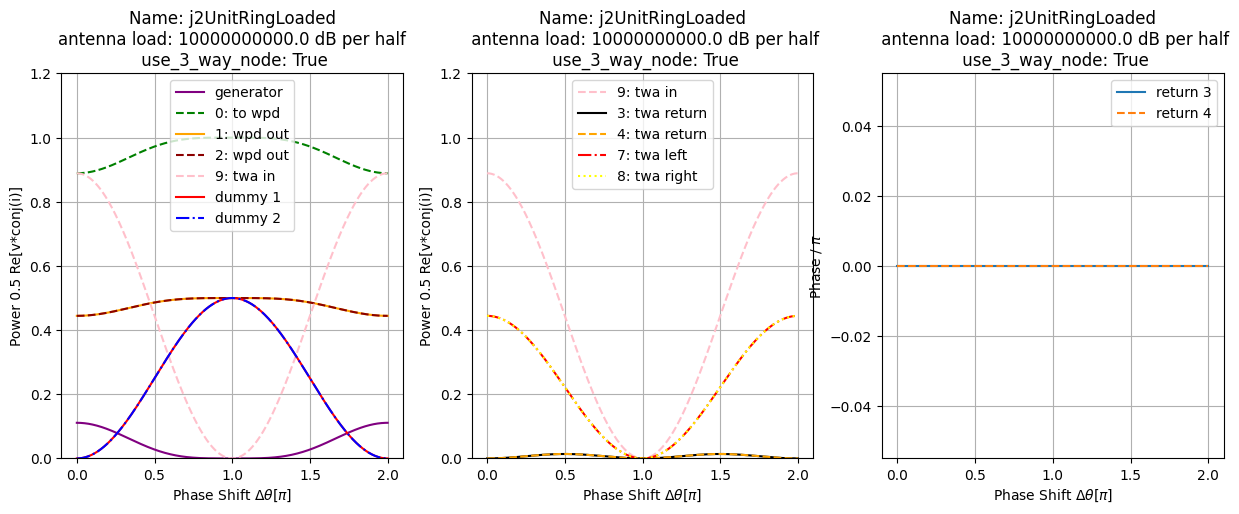

In [210]:
# plot 
fig, ax = plt.subplots(1,3,figsize=(15,5))

ax[0].plot(phase_array/np.pi, np.abs(generator_phasor_array)**2, label='generator', color='purple')

if use_3_way_node:
    ax[0].plot(phase_array/np.pi, int_generator_phasor_array_0, label='0: to wpd',color='green', linestyle='--')
    ax[0].plot(phase_array/np.pi, wpd1_out_phasor_array_1, label='1: wpd out',color='orange', linestyle='solid')
    ax[0].plot(phase_array/np.pi, wpd1_out_phasor_array_2, label='2: wpd out',color='darkred', linestyle='--')
    ax[0].plot(phase_array/np.pi, twa_infeed_phasor_array_9, label='9: twa in',color='pink', linestyle='--')

# plot the circulating power on the other axis
if use_3_way_node:
    ax[1].plot(phase_array/np.pi, twa_infeed_phasor_array_9, label='9: twa in',color='pink', linestyle='--') 
    ax[1].plot(phase_array/np.pi, twa_return_phasor_array_3, label='3: twa return',color='black')
    ax[1].plot(phase_array/np.pi, twa_return_phasor_array_4, label='4: twa return',color='orange', linestyle='--')
    ax[1].plot(phase_array/np.pi, twa_split_power_phasor_array_7, label='7: twa left',color='red', linestyle='-.')
    ax[1].plot(phase_array/np.pi, twa_split_power_phasor_array_8, label='8: twa right',color='yellow', linestyle=':')

ax[0].plot(phase_array/np.pi, np.abs(dummy_load1_phasor_array)**2, label='dummy 1', linestyle='solid', color='red')
ax[0].plot(phase_array/np.pi, np.abs(dummy_load2_phasor_array)**2, label='dummy 2', linestyle='-.', color='blue')

ax[0].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[0].set_ylabel(r'Power 0.5 Re[v*conj(i)]')
ax[0].legend()
ax[0].set_ylim(0,1.2)
ax[1].set_ylim(0,1.2)
ax[0].grid()
title_string = f'{loaded_j.name}\nantenna load: {antload} dB per half\n use_3_way_node: {use_3_way_node}'
ax[0].set_title(f'Name: {title_string}')

ax[1].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[1].set_ylabel(r'Power 0.5 Re[v*conj(i)]')
ax[1].legend()
ax[1].grid()
title_string = f'{loaded_j.name}\n antenna load: {antload} dB per half\n use_3_way_node: {use_3_way_node}'
ax[1].set_title(f'Name: {title_string}')


ax[2].plot(phase_array/np.pi, twa_return_phase_array_3, label='return 3')
ax[2].plot(phase_array/np.pi, twa_return_phase_array_4, label='return 4', linestyle='--')
ax[2].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[2].set_ylabel(r'Phase / $\pi$')
ax[2].legend()
ax[2].grid()
title_string = f'{loaded_j.name}\n antenna load: {antload} dB per half\n use_3_way_node: {use_3_way_node}'
ax[2].set_title(f'Name: {title_string}')



In [211]:
# test out the simple 2-port TWA model. 
#get_circuit_loaded_simple_TWA_wunit_ring(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, use_3_way_node=False, name='wUnitRing1'):

antload = 10 # db ohm, keep < z0 = 50 for small loading 


#phase = [np.pi/2, np.pi/2, np.pi/2]

phase_array = np.linspace(0, 2*np.pi, 400)
# dphi = 0
# twa_return1_power_factor = 1
# twa_return2_power_factor = 1

# response arrays for plotting 
generator_phasor_array = np.zeros_like(phase_array, dtype=complex)


dummy_load1_phasor_array = np.zeros_like(phase_array, dtype=complex)

# make other storage arrays for internal powers within antenna ring network 

int_generator_phasor_array_0 = np.zeros_like(phase_array)
twa_return_phasor_array_1 = np.zeros_like(phase_array)
twa_infeed_power_phasor_array_4 = np.zeros_like(phase_array)

twa_return_phase_array_1 = np.zeros_like(phase_array)
# junit_ring_network = get_circuit_junit_ring(freq, z0=50, phase_shifter_phase_shift_array=phase, return_circuit=False, name='jUnitRing1')
# s_junit_ring_network = junit_ring_network.s[0,:,:]


for i in range(phase_array.shape[0]):
    # grab the loaded j unit ring s matrix for the given phase shiftor phase. Allow the ring to set up the resonance correctly 
    loaded_j, loaded_j_circ = get_circuit_loaded_simple_TWA_wunit_ring(freq, z0=50, phase_shifter_phase_shift_array=[phase_array[i], phase_array[i]], R=antload, return_circuit=True, use_3_way_node=use_3_way_node, name='simple TWA 2-port')
    s_loaded_j_unit_ring_network = loaded_j.s[0,:,:]
    excitation = np.array([1,
                           0]).T
    
    result = np.matmul(s_loaded_j_unit_ring_network, excitation)
    generator_phasor_array[i] = result[0]
    dummy_load1_phasor_array[i] = result[1]

    # now, probe the powers in the internal ports. 

    currents = branch_currents(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
    voltages = branch_voltages(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
    powers = branch_powers(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
    
    # load up the power vectors 
    int_generator_phasor_array_0[i] = np.abs(powers[0][0])
    twa_return_phasor_array_1[i] = np.abs(powers[0][1])
    twa_infeed_power_phasor_array_4[i] = np.abs(powers[0][4])
    twa_return_phase_array_1[i] = np.arctan2(np.imag(powers[0][1]), np.real(powers[0][1]))/np.pi



Text(0.5, 1.0, 'Name: simple TWA 2-port\n antenna load: 10 dB per half\n use_3_way_node: True')

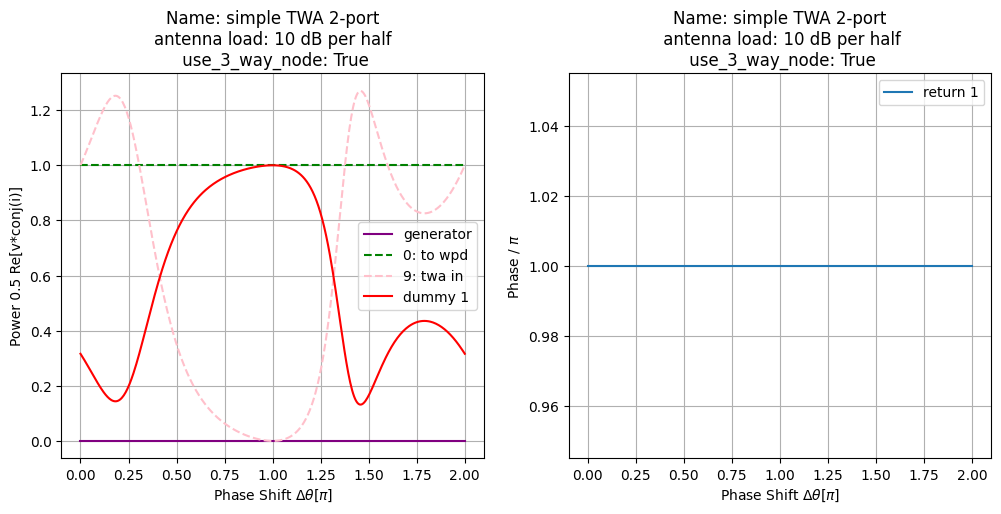

In [212]:
# plot 
fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(phase_array/np.pi, np.abs(generator_phasor_array)**2, label='generator', color='purple')
ax[0].plot(phase_array/np.pi, int_generator_phasor_array_0, label='0: to wpd',color='green', linestyle='--')
ax[0].plot(phase_array/np.pi, twa_infeed_power_phasor_array_4, label='9: twa in',color='pink', linestyle='--')
ax[0].plot(phase_array/np.pi, np.abs(dummy_load1_phasor_array)**2, label='dummy 1', linestyle='solid', color='red')


ax[0].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[0].set_ylabel(r'Power 0.5 Re[v*conj(i)]')
ax[0].legend()
# ax[0].set_ylim(0,1.2)
# ax[1].set_ylim(0,1.2)
ax[0].grid()
title_string = f'{loaded_j.name}\nantenna load: {antload} dB per half\n use_3_way_node: {use_3_way_node}'
ax[0].set_title(f'Name: {title_string}')


ax[1].plot(phase_array/np.pi, twa_return_phase_array_1, label='return 1')
ax[1].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[1].set_ylabel(r'Phase / $\pi$')
ax[1].legend()
ax[1].grid()
title_string = f'{loaded_j.name}\n antenna load: {antload} dB per half\n use_3_way_node: {use_3_way_node}'
ax[1].set_title(f'Name: {title_string}')

In [213]:
# test out the loaded but seperated rings to see if the wilkinson at the antenna split was to blame. 

#get_circuit_loaded_2wunit_isolated_rings(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, name='wUnitIsorings')

antload = 10 # db ohm, keep < z0 = 50 for small loading 


#phase = [np.pi/2, np.pi/2, np.pi/2]

phase_array = np.linspace(0, 2*np.pi, 400)
# dphi = 0
# twa_return1_power_factor = 1
# twa_return2_power_factor = 1

# response arrays for plotting 
generator_phasor_array = np.zeros_like(phase_array, dtype=complex)


dummy_load1_phasor_array = np.zeros_like(phase_array, dtype=complex)
dummy_load2_phasor_array = np.zeros_like(phase_array, dtype=complex)

# make other storage arrays for internal powers within antenna ring network 

int_generator_phasor_array_0 = np.zeros_like(phase_array)
twa_return1_phasor_array_7 = np.zeros_like(phase_array)
twa_return2_phasor_array_8 = np.zeros_like(phase_array)
twa_infeed1_power_phasor_array_9 = np.zeros_like(phase_array)
twa_infeed2_power_phasor_array_10 = np.zeros_like(phase_array)

twa_return1_phase_array_7 = np.zeros_like(phase_array)
twa_return2_phase_array_8 = np.zeros_like(phase_array)
# junit_ring_network = get_circuit_junit_ring(freq, z0=50, phase_shifter_phase_shift_array=phase, return_circuit=False, name='jUnitRing1')
# s_junit_ring_network = junit_ring_network.s[0,:,:]


for i in range(phase_array.shape[0]):
    # grab the loaded j unit ring s matrix for the given phase shiftor phase. Allow the ring to set up the resonance correctly 
    loaded_j, loaded_j_circ = get_circuit_loaded_2wunit_isolated_rings(freq, z0=50, phase_shifter_phase_shift_array=[phase_array[i], phase_array[i]], R=antload, return_circuit=True, name='2 isolated TWA rings')
    s_loaded_j_unit_ring_network = loaded_j.s[0,:,:]
    excitation = np.array([1,
                           0,
                           0]).T
    
    result = np.matmul(s_loaded_j_unit_ring_network, excitation)
    generator_phasor_array[i] = result[0]
    dummy_load1_phasor_array[i] = result[1]
    dummy_load2_phasor_array[i] = result[2]

    # now, probe the powers in the internal ports. 

    currents = branch_currents(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
    voltages = branch_voltages(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
    powers = branch_powers(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
    
    # load up the power vectors 
    int_generator_phasor_array_0[i] = np.abs(powers[0][0])
    twa_return1_phasor_array_7[i] = np.abs(powers[0][7])
    twa_return2_phasor_array_8[i] = np.abs(powers[0][8])
    twa_infeed1_power_phasor_array_9[i] = np.abs(powers[0][9])
    twa_infeed2_power_phasor_array_10[i] = np.abs(powers[0][10])
    twa_return1_phase_array_7[i] = np.arctan2(np.imag(powers[0][7]), np.real(powers[0][7]))/np.pi
    twa_return2_phase_array_8[i] = np.arctan2(np.imag(powers[0][8]), np.real(powers[0][8]))/np.pi

Text(0.5, 1.0, 'Name: 2 isolated TWA rings\n antenna load: 10 dB per half\n')

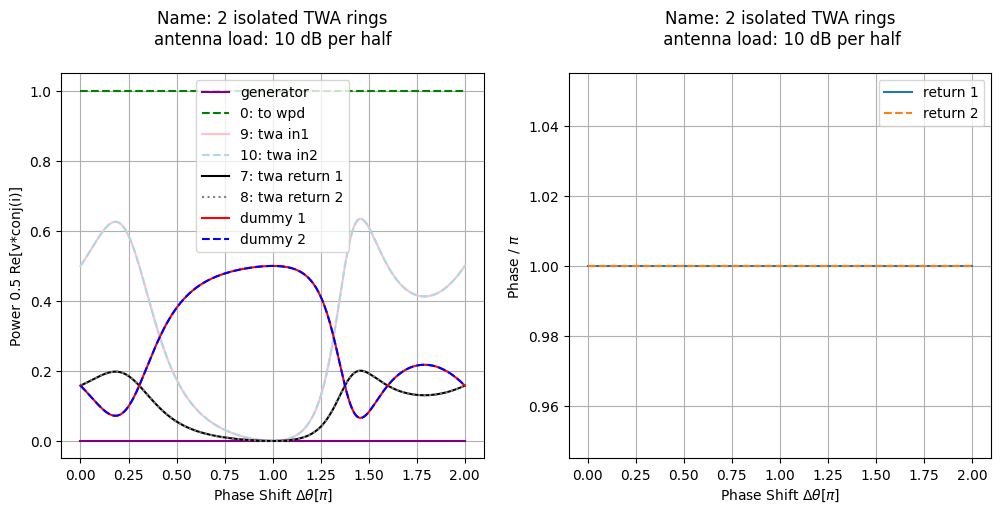

In [214]:
# plot 
fig, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].plot(phase_array/np.pi, np.abs(generator_phasor_array)**2, label='generator', color='purple')
ax[0].plot(phase_array/np.pi, int_generator_phasor_array_0, label='0: to wpd',color='green', linestyle='--')
ax[0].plot(phase_array/np.pi, twa_infeed1_power_phasor_array_9, label='9: twa in1',color='pink', linestyle='solid')
ax[0].plot(phase_array/np.pi, twa_infeed2_power_phasor_array_10, label='10: twa in2',color='lightblue', linestyle='--')
ax[0].plot(phase_array/np.pi, twa_return1_phasor_array_7, label='7: twa return 1',color='black', linestyle='solid')
ax[0].plot(phase_array/np.pi, twa_return2_phasor_array_8, label='8: twa return 2',color='grey', linestyle=':')
ax[0].plot(phase_array/np.pi, np.abs(dummy_load1_phasor_array)**2, label='dummy 1', linestyle='solid', color='red')
ax[0].plot(phase_array/np.pi, np.abs(dummy_load2_phasor_array)**2, label='dummy 2', linestyle='--', color='blue')


ax[0].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[0].set_ylabel(r'Power 0.5 Re[v*conj(i)]')
ax[0].legend()
# ax[0].set_ylim(0,1.2)
# ax[1].set_ylim(0,1.2)
ax[0].grid()
title_string = f'{loaded_j.name}\nantenna load: {antload} dB per half\n'
ax[0].set_title(f'Name: {title_string}')


ax[1].plot(phase_array/np.pi, twa_return1_phase_array_7, label='return 1')
ax[1].plot(phase_array/np.pi, twa_return2_phase_array_8, label='return 2', linestyle='--')
ax[1].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[1].set_ylabel(r'Phase / $\pi$')
ax[1].legend()
ax[1].grid()
title_string = f'{loaded_j.name}\n antenna load: {antload} dB per half\n'
ax[1].set_title(f'Name: {title_string}')

In [240]:
# try out the three port lossy antenna model 
#get_circuit_loaded_wunit2wpd2_ring_1ant(freq, z0, phase_shifter_phase_shift_array, R, return_circuit=False, name='wunit 3 port ant')


antload = 5 # db ohm, keep < z0 = 50 for small loading 

# test out loaded junit circuit model 

#phase = [np.pi/2, np.pi/2, np.pi/2]

phase_array = np.linspace(0, 2*np.pi, 400)
# dphi = 0
# twa_return1_power_factor = 1
# twa_return2_power_factor = 1

# response arrays for plotting 
generator_phasor_array = np.zeros_like(phase_array, dtype=complex)


dummy_load1_phasor_array = np.zeros_like(phase_array, dtype=complex)
dummy_load2_phasor_array = np.zeros_like(phase_array, dtype=complex)

# make other storage arrays for internal powers within antenna ring network 

int_generator_phasor_array_0 = np.zeros_like(phase_array)
wpd1_out_phasor_array_1 = np.zeros_like(phase_array)
wpd1_out_phasor_array_2 = np.zeros_like(phase_array)
twa_return_phasor_array_3 = np.zeros_like(phase_array)
twa_return_phasor_array_4 = np.zeros_like(phase_array)
twa_infeed_phasor_array_7 = np.zeros_like(phase_array)

twa_return_phase_array_3 = np.zeros_like(phase_array)
twa_return_phase_array_4 = np.zeros_like(phase_array)

# junit_ring_network = get_circuit_junit_ring(freq, z0=50, phase_shifter_phase_shift_array=phase, return_circuit=False, name='jUnitRing1')
# s_junit_ring_network = junit_ring_network.s[0,:,:]


for i in range(phase_array.shape[0]):
    # grab the loaded j unit ring s matrix for the given phase shiftor phase. Allow the ring to set up the resonance correctly 
    loaded_j, loaded_j_circ = get_circuit_loaded_wunit2wpd2_ring_1ant(freq, z0=50, phase_shifter_phase_shift_array=[phase_array[i], phase_array[i], phase_array[i]], R=antload, return_circuit=True, name='3 port lossy antenna')
    s_loaded_j_unit_ring_network = loaded_j.s[0,:,:]
    excitation = np.array([1,
                           0,
                           0]).T
    
    result = np.matmul(s_loaded_j_unit_ring_network, excitation)
    generator_phasor_array[i] = result[0]
    dummy_load1_phasor_array[i] = result[1]
    dummy_load2_phasor_array[i] = result[2]

    # now, probe the powers in the internal ports. 
    currents = branch_currents(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
    voltages = branch_voltages(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
    powers = branch_powers(circuit=loaded_j_circ, power=excitation, phase=excitation*0)
    
    # load up the power vectors 
    int_generator_phasor_array_0[i] = np.abs(powers[0][0])
    wpd1_out_phasor_array_1[i] = np.abs(powers[0][1])
    wpd1_out_phasor_array_2[i] = np.abs(powers[0][2])
    twa_return_phasor_array_3[i] = np.abs(powers[0][3])
    twa_return_phasor_array_4[i] = np.abs(powers[0][4])
    twa_infeed_phasor_array_7[i] = np.abs(powers[0][7])
    twa_return_phase_array_3[i] = np.arctan2(np.imag(powers[0][3]), np.real(powers[0][3]))/np.pi
    twa_return_phase_array_4[i] = np.arctan2(np.imag(powers[0][4]), np.real(powers[0][4]))/np.pi


Text(0.5, 1.0, 'Name: 3 port lossy antenna\n antenna load: 5 dB per half')

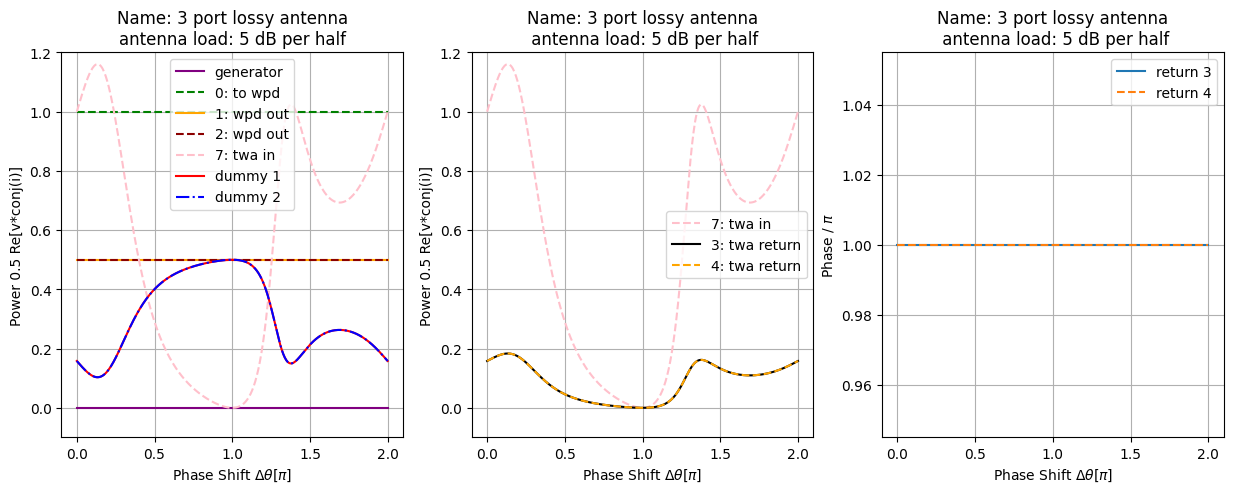

In [241]:
fig, ax = plt.subplots(1,3,figsize=(15,5))

ax[0].plot(phase_array/np.pi, np.abs(generator_phasor_array)**2, label='generator', color='purple')
ax[0].plot(phase_array/np.pi, int_generator_phasor_array_0, label='0: to wpd',color='green', linestyle='--')
ax[0].plot(phase_array/np.pi, wpd1_out_phasor_array_1, label='1: wpd out',color='orange', linestyle='solid')
ax[0].plot(phase_array/np.pi, wpd1_out_phasor_array_2, label='2: wpd out',color='darkred', linestyle='--')
ax[0].plot(phase_array/np.pi, twa_infeed_phasor_array_7, label='7: twa in',color='pink', linestyle='--')

# plot the circulating power on the other axis
ax[1].plot(phase_array/np.pi, twa_infeed_phasor_array_7, label='7: twa in',color='pink', linestyle='--') 
ax[1].plot(phase_array/np.pi, twa_return_phasor_array_3, label='3: twa return',color='black')
ax[1].plot(phase_array/np.pi, twa_return_phasor_array_4, label='4: twa return',color='orange', linestyle='--')

ax[0].plot(phase_array/np.pi, np.abs(dummy_load1_phasor_array)**2, label='dummy 1', linestyle='solid', color='red')
ax[0].plot(phase_array/np.pi, np.abs(dummy_load2_phasor_array)**2, label='dummy 2', linestyle='-.', color='blue')

ax[0].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[0].set_ylabel(r'Power 0.5 Re[v*conj(i)]')
ax[0].legend()
ax[0].set_ylim(-.1,1.2)
ax[1].set_ylim(-.1,1.2)
ax[0].grid()
title_string = f'{loaded_j.name}\nantenna load: {antload} dB per half'
ax[0].set_title(f'Name: {title_string}')

ax[1].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[1].set_ylabel(r'Power 0.5 Re[v*conj(i)]')
ax[1].legend()
ax[1].grid()
title_string = f'{loaded_j.name}\n antenna load: {antload} dB per half'
ax[1].set_title(f'Name: {title_string}')


ax[2].plot(phase_array/np.pi, twa_return_phase_array_3, label='return 3')
ax[2].plot(phase_array/np.pi, twa_return_phase_array_4, label='return 4', linestyle='--')
ax[2].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[2].set_ylabel(r'Phase / $\pi$')
ax[2].legend()
ax[2].grid()
title_string = f'{loaded_j.name}\n antenna load: {antload} dB per half'
ax[2].set_title(f'Name: {title_string}')

In [215]:
# test out junit2 circuit model 

phase = [np.pi/2, np.pi/2, np.pi/2]

phase_mismatch_array = np.linspace(0, 2*np.pi, 400)
# dphi = 0
# twa_return1_power_factor = 1
# twa_return2_power_factor = 1

# response arrays for plotting 
generator_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_return1_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_return2_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
twa_out_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)

dummy_load1_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
dummy_load2_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)
dummy_load3_phasor_array = np.zeros_like(phase_mismatch_array, dtype=complex)



junit_ring_network = get_circuit_junit_ring_2(freq, z0=50, phase_shifter_phase_shift_array=phase, return_circuit=False, name='jUnitRing1')
s_junit_ring_network = junit_ring_network.s[0,:,:]


for i in range(phase_mismatch_array.shape[0]):
    # excite the generator and a matching phase mismatch for the two antenna returns
    # note the WPD sets the generator phase back by 90 deg for the two WPD outputs,
    # so to scan with idential inputs returning from TWA, need initial -90 deg 
    excitation = np.array([1,
                           (twa_return1_power_factor*1/np.sqrt(2))*np.exp(-1j*np.pi/2)*np.exp(1j*phase_mismatch_array[i]),
                           (twa_return2_power_factor*1/np.sqrt(2))*np.exp(-1j*np.pi/2)*np.exp(1j*(phase_mismatch_array[i] + dphi)),
                           0,
                           0,
                           0,
                           0]).T
    
    result = np.matmul(s_junit_ring_network, excitation)
    generator_phasor_array[i] = result[0]
    twa_return1_phasor_array[i] = result[1]
    twa_return2_phasor_array[i] = result[2]
    twa_out_phasor_array[i] = result[3]

    dummy_load1_phasor_array[i] = result[4]
    dummy_load2_phasor_array[i] = result[5]
    dummy_load3_phasor_array[i] = result[6]

Text(0.5, 1.0, 'Name: jUnitRing1\ndphi: 0.000 degrees\nTWA return power factor 1,2: 10.00, 10.00')

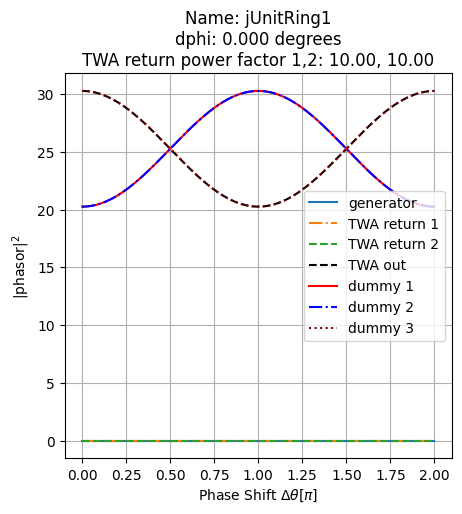

In [216]:
# plot 
fig, ax = plt.subplots(1,1,figsize=(5,5))

ax.plot(phase_mismatch_array/np.pi, np.abs(generator_phasor_array)**2, label='generator')
ax.plot(phase_mismatch_array/np.pi, np.abs(twa_return1_phasor_array)**2, label='TWA return 1', linestyle='-.')
ax.plot(phase_mismatch_array/np.pi, np.abs(twa_return2_phasor_array)**2, label='TWA return 2', linestyle='--')
ax.plot(phase_mismatch_array/np.pi, np.abs(twa_out_phasor_array)**2, label='TWA out', linestyle='--', color='black')

ax.plot(phase_mismatch_array/np.pi, np.abs(dummy_load1_phasor_array)**2, label='dummy 1', linestyle='solid', color='red')
ax.plot(phase_mismatch_array/np.pi, np.abs(dummy_load2_phasor_array)**2, label='dummy 2', linestyle='-.', color='blue')
ax.plot(phase_mismatch_array/np.pi, np.abs(dummy_load3_phasor_array)**2, label='dummy 3', linestyle=':', color='maroon')


ax.set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()
ax.grid()
title_string = f'{junit_ring_network.name}\n' \
    + f'dphi: {dphi*180/np.pi:.3f} degrees\n' \
    + f'TWA return power factor 1,2: {twa_return1_power_factor:.2f}, {twa_return2_power_factor:.2f}'
ax.set_title(f'Name: {title_string}')

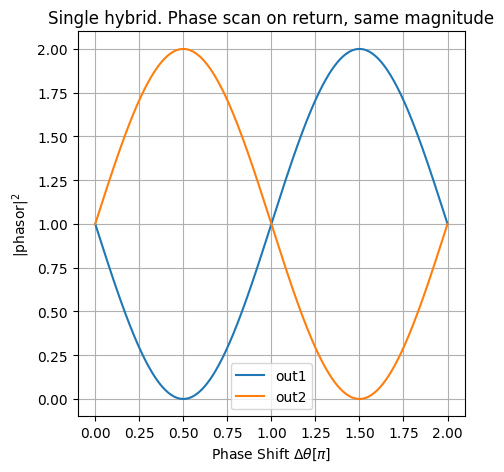

In [217]:
# carfully determine behavior of a single hybrid.
f = np.array([96]) # not important, assume our componants are chosen for this frequency. 
freq = rf.Frequency.from_f(f, unit='MHz')


hybrid = get_network_90deg_hybrid(freq, z0=50, name='90deg hybrid 1')

S = hybrid.s[0,:,:]

phase_array = np.linspace(0, 2*np.pi, 400)
out1 = np.zeros_like(phase_array, dtype=complex)
out2 = np.zeros_like(phase_array, dtype=complex)

for i in range(phase_array.shape[0]):
    excitation = np.array([np.exp(1j*phase_array[i]),
                           0,
                           0,
                           1], dtype=complex).T
    result = np.matmul(S, excitation)
    out1[i] = result[1]
    out2[i] = result[2]


fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(phase_array/np.pi, np.abs(out1)**2, label='out1')
ax.plot(phase_array/np.pi, np.abs(out2)**2, label='out2')
ax.grid()
ax.set_title('Single hybrid. Phase scan on return, same magnitude')
ax.set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()

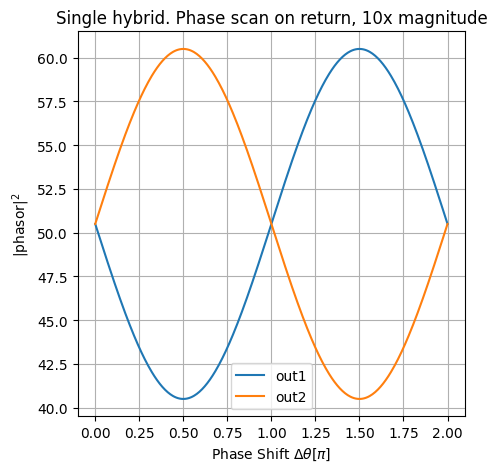

In [218]:
f = np.array([96]) # not important, assume our componants are chosen for this frequency. 
freq = rf.Frequency.from_f(f, unit='MHz')


hybrid = get_network_90deg_hybrid(freq, z0=50, name='90deg hybrid 1')

S = hybrid.s[0,:,:]
A = 10

phase_array = np.linspace(0, 2*np.pi, 400)
out1 = np.zeros_like(phase_array, dtype=complex)
out2 = np.zeros_like(phase_array, dtype=complex)

for i in range(phase_array.shape[0]):
    excitation = np.array([A*np.exp(1j*phase_array[i]),
                           0,
                           0,
                           1], dtype=complex).T
    result = np.matmul(S, excitation)
    out1[i] = result[1]
    out2[i] = result[2]


fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(phase_array/np.pi, np.abs(out1)**2, label='out1')
ax.plot(phase_array/np.pi, np.abs(out2)**2, label='out2')
ax.grid()
ax.set_title('Single hybrid. Phase scan on return, 10x magnitude')
ax.set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()

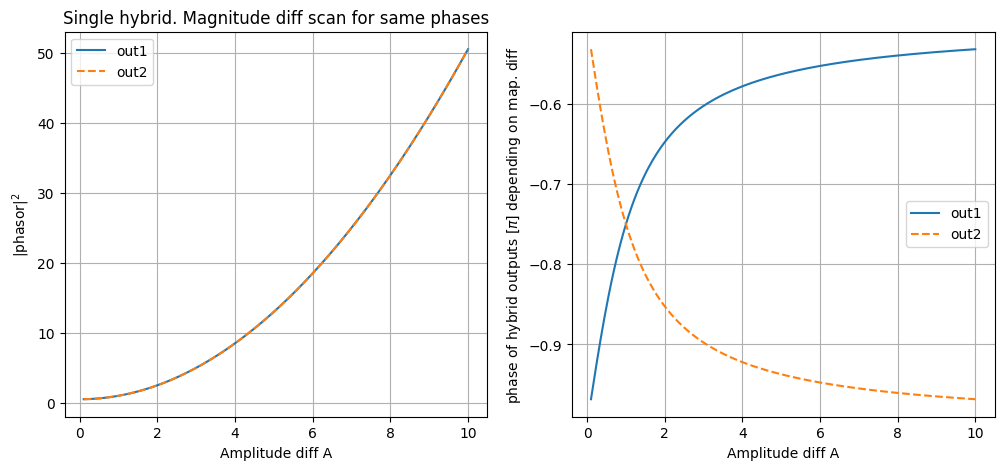

In [219]:
f = np.array([96]) # not important, assume our componants are chosen for this frequency. 
freq = rf.Frequency.from_f(f, unit='MHz')


hybrid = get_network_90deg_hybrid(freq, z0=50, name='90deg hybrid 1')

S = hybrid.s[0,:,:]
A = np.linspace(0.1, 10, 400)

phase_array = np.linspace(0, 2*np.pi, 400)*0 # set to zero deg 
out1 = np.zeros_like(phase_array, dtype=complex)
out2 = np.zeros_like(phase_array, dtype=complex)

for i in range(phase_array.shape[0]):
    excitation = np.array([A[i]*np.exp(1j*phase_array[i]),
                           0,
                           0,
                           1], dtype=complex).T
    result = np.matmul(S, excitation)
    out1[i] = result[1]
    out2[i] = result[2]


fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(A, np.abs(out1)**2, label='out1')
ax[0].plot(A, np.abs(out2)**2, label='out2', linestyle='--')
ax[0].grid()
ax[0].set_title('Single hybrid. Magnitude diff scan for same phases')
ax[0].set_xlabel('Amplitude diff A')
ax[0].set_ylabel(r'|phasor|$^2$')
ax[0].legend()

ax[1].plot(A, np.arctan2(np.imag(out1), np.real(out1))/np.pi, label='out1')
ax[1].plot(A, np.arctan2(np.imag(out2), np.real(out2))/np.pi, linestyle='--', label='out2')
ax[1].set_xlabel('Amplitude diff A')
ax[1].set_ylabel(r'phase of hybrid outputs [$\pi$] depending on map. diff')
ax[1].grid()
ax[1].legend()

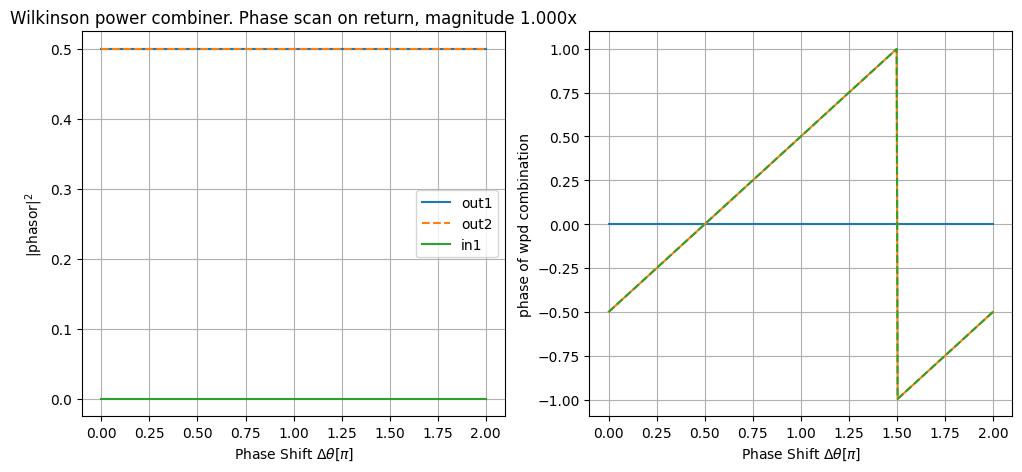

In [220]:
# now, carfully check the wilkonsin power divider/combiner 

wpd = get_network_wilkinson_power_divider(freq, z0=50, name='pwrdv 1')

S = wpd.s[0,:,:]
A = 1

phase_array = np.linspace(0, 2*np.pi, 400)
out1 = np.zeros_like(phase_array, dtype=complex)
out2 = np.zeros_like(phase_array, dtype=complex)
in1 = np.zeros_like(phase_array, dtype=complex)

for i in range(phase_array.shape[0]):
    excitation = np.array([A*np.exp(1j*phase_array[i]),
                           0,
                           0], dtype=complex).T
    result = np.matmul(S, excitation)
    in1[i] = result[0]
    out1[i] = result[1]
    out2[i] = result[2]


fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(phase_array/np.pi, np.abs(out1)**2, label='out1')
ax[0].plot(phase_array/np.pi, np.abs(out2)**2, label='out2', linestyle = '--')
ax[0].plot(phase_array/np.pi, np.abs(in1)**2, label='in1')
ax[0].grid()
ax[0].set_title(f'Wilkinson power combiner. Phase scan on return, magnitude {A:.3f}x')
ax[0].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[0].set_ylabel(r'|phasor|$^2$')
ax[0].legend()

ax[1].plot(phase_array/np.pi, np.arctan2(np.imag(in1), np.real(in1))/np.pi, label='in1')
ax[1].plot(phase_array/np.pi, np.arctan2(np.imag(out1), np.real(out1))/np.pi, label='out1')
ax[1].plot(phase_array/np.pi, np.arctan2(np.imag(out2), np.real(out2))/np.pi, linestyle='--', label='out2')
ax[1].set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax[1].set_ylabel(r'phase of wpd combination')
ax[1].grid()


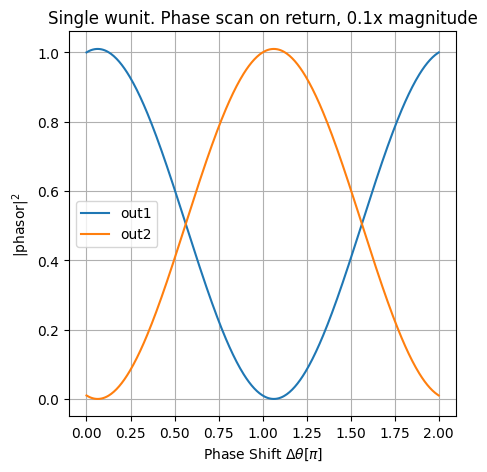

In [221]:
# looking at the w-unit 

f = np.array([96]) # not important, assume our componants are chosen for this frequency. 
freq = rf.Frequency.from_f(f, unit='MHz')


A = .1

phase_array = np.linspace(0, 2*np.pi, 400)
out1 = np.zeros_like(phase_array, dtype=complex)
out2 = np.zeros_like(phase_array, dtype=complex)


for i in range(phase_array.shape[0]):
    wunit = get_network_wunit(freq=freq, z0=50, phase_shifter_phase_shift=phase_array[i], return_circuit=False, name='wunit 1')
    S = wunit.s[0,:,:]
    excitation = np.array([A,
                           0,
                           0,
                           1], dtype=complex).T
    result = np.matmul(S, excitation)
    out1[i] = result[1]
    out2[i] = result[2]


fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(phase_array/np.pi, np.abs(out1)**2, label='out1')
ax.plot(phase_array/np.pi, np.abs(out2)**2, label='out2')
ax.grid()
ax.set_title(f'Single wunit. Phase scan on return, {A}x magnitude')
ax.set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()




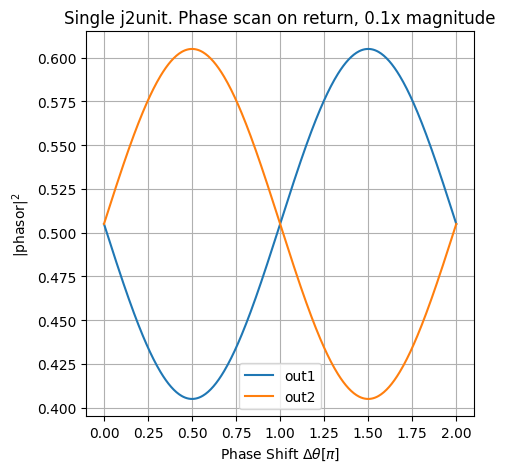

In [ ]:
# looking at the j2-unit 

f = np.array([96]) # not important, assume our componants are chosen for this frequency. 
freq = rf.Frequency.from_f(f, unit='MHz')


A = .1

phase_array = np.linspace(0, 2*np.pi, 400)
out1 = np.zeros_like(phase_array, dtype=complex)
out2 = np.zeros_like(phase_array, dtype=complex)


for i in range(phase_array.shape[0]):
    wunit = get_network_j2unit(freq=freq, z0=50, phase_shifter_phase_shift=phase_array[i], return_circuit=False, name='wunit 1')
    S = wunit.s[0,:,:]
    excitation = np.array([A,
                           0,
                           0,
                           1], dtype=complex).T
    result = np.matmul(S, excitation)
    out1[i] = result[1]
    out2[i] = result[2]


fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(phase_array/np.pi, np.abs(out1)**2, label='out1')
ax.plot(phase_array/np.pi, np.abs(out2)**2, label='out2')
ax.grid()
ax.set_title(f'Single j2unit. Phase scan on return, {A}x magnitude')
ax.set_xlabel('Phase Shift' r' $\Delta \theta [\pi$]')
ax.set_ylabel(r'|phasor|$^2$')
ax.legend()